# Explainable Offline Deep Reinforcement Learning and XAI Validation for Dairy Supply Chain Optimization


## Setup Device


In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Ignore Warning


In [2]:
import warnings

warnings.filterwarnings("ignore")

## Creating Directory


In [3]:
from pathlib import Path

# Define your directory path
dir_path = Path("./plots")

# Create directory safely
dir_path.mkdir(parents=True, exist_ok=True)

# Define your directory path
dir_path = Path("./results")

# Create directory safely
dir_path.mkdir(parents=True, exist_ok=True)

## Research-Grade Visualization


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (12, 7),
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif"],
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "lines.linewidth": 2.0,
        "grid.alpha": 0.3,
        "grid.linestyle": "--",
        "axes.linewidth": 1.2,
    }
)
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

## Load Data


In [5]:
import os
import kagglehub
import pandas as pd

print("Loading data...")
path = kagglehub.dataset_download("debarghamitraroy/dairy-production-dataset")
data_path = os.path.join(path, "train.csv")
df = pd.read_csv(data_path)
print("Data loading was successful...")

Loading data...
Data loading was successful...


In [6]:
num_rows, num_cols = df.shape
print(f"Rows: {num_rows}")
print(f"Columns: {num_cols}")

Rows: 122983
Columns: 24


## Environment Formulation & Offline Data Engineering


### Temporal Feature Engineering


In [7]:
print("Processing temporal features...")

# Convert date columns to datetime objects dates are in DD-MM-YYYY format
date_cols = ["Date", "Production Date", "Expiration Date"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format="%d-%m-%Y", errors="coerce")

# Calculate 'Days to Expiration'
# This is the exact number of days left from the current transaction 'Date' until the product spoils.
df["Days_to_Expiration"] = (df["Expiration Date"] - df["Date"]).dt.days

# Drop rows where expiration is negative (already spoiled before the record date) or where dates are missing due to parsing errors.
df = df[df["Days_to_Expiration"] >= 0].copy()

# Calculate Age of product since production
df["Product_Age_Days"] = (df["Date"] - df["Production Date"]).dt.days

print("Processing temporal features was successful...")

Processing temporal features...
Processing temporal features was successful...


#### Age-Structured Inventory Matrix (FIFO)


In [8]:
print("Building FIFO age-structured matrices...")
# In Deep RL, the agent needs a fixed-size vector to understand inventory age.
# We will create a vector up to 'MAX_SHELF_LIFE' (e.g., 30 days).
# Bins: [Expiring in 0-2 days, 3-5 days, ..., 20+ days]

MAX_SHELF_LIFE = 30  # Cap for the maximum days we track individually

# Pivot the data to create a state vector for each Product ID on each Date
# We group by Date and Product ID, and sum the Quantity in Stock for each expiration day.
fifo_matrix = df.pivot_table(
    index=["Date", "Product ID"],
    columns="Days_to_Expiration",
    values="Quantity in Stock (liters/kg)",
    aggfunc="sum",
    fill_value=0,
)

# Truncate and group columns beyond MAX_SHELF_LIFE to prevent infinite state space expansion
cols_to_keep = [col for col in fifo_matrix.columns if col <= MAX_SHELF_LIFE]
cols_to_group = [col for col in fifo_matrix.columns if col > MAX_SHELF_LIFE]

if cols_to_group:
    fifo_matrix[f">{MAX_SHELF_LIFE}_Days"] = fifo_matrix[cols_to_group].sum(axis=1)
    fifo_matrix = fifo_matrix.drop(columns=cols_to_group)

# Rename columns for clarity in the RL State Vector
fifo_matrix.columns = [
    f"Stock_Expiring_in_{int(col)}_Days" if isinstance(col, (int, float)) else col
    for col in fifo_matrix.columns
]

print(f"Created FIFO matrix with shape: {fifo_matrix.shape}")
# You can merge this back into your main environment dataframe using the Date and Product ID indices.

Building FIFO age-structured matrices...
Created FIFO matrix with shape: (56546, 32)


#### Multicollinearity Detection


In [9]:
import numpy as np

print("Analyzing Multicollinearity for XAI ROAR/PI evaluation...")

# Select only numerical columns for correlation
numerical_df = df.select_dtypes(include=[np.number])

# Calculate the Pearson correlation matrix
corr_matrix = numerical_df.corr().abs()

# Create a mask to ignore the diagonal and the lower triangle (to avoid duplicate pairs)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Set a threshold for identifying highly collinear features
COLLINEAR_THRESHOLD = 0.85

# Find index pairs with correlation above the threshold
collinear_pairs = [
    (upper_tri.columns[i], upper_tri.columns[j], upper_tri.iloc[i, j])
    for i in range(len(upper_tri.columns))
    for j in range(i + 1, len(upper_tri.columns))
    if upper_tri.iloc[i, j] > COLLINEAR_THRESHOLD
]

print(f"\nHighly Collinear Feature Pairs (Threshold > {COLLINEAR_THRESHOLD}):")

for feat1, feat2, corr_val in collinear_pairs:
    print(f"[{corr_val:.3f}] {feat1} <--> {feat2}")

Analyzing Multicollinearity for XAI ROAR/PI evaluation...

Highly Collinear Feature Pairs (Threshold > 0.85):
[0.988] Price per Unit <--> Price per Unit (sold)


### State & Action Formulation


#### Create the RL Environment DataFrame


In [10]:
# Merge FIFO into main dataframe to create the raw RL Environment DataFrame
rl_df = df.merge(fifo_matrix, on=["Date", "Product ID"], how="left")

# Fill NaNs with 0 for days where no stock is expiring in that specific bin
rl_df.fillna(0, inplace=True)

# Shape of the RL Environment dataframe
print("Shape:", rl_df.shape)

Shape: (60035, 58)


#### Encode Categorical Variables


In [11]:
import joblib
from pathlib import Path
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Neural networks require numeric inputs. We encode string categories into integers.
print("Encoding categorical variables...")
categorical_cols = [
    "Location",
    "Farm Size",
    "Product Name",
    "Brand",
    "Storage Condition",
    "Sales Channel",
]
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    rl_df[col] = le.fit_transform(rl_df[col].astype(str))
    encoders[col] = le

# Save encoders for later decoding during XAI rule extraction
# Path("./model").mkdir(parents=True, exist_ok=True)
# joblib.dump(encoders, "./model/LMUT_MOET_categorical_encoders.pkl")

Encoding categorical variables...


#### Define State (S) Features


In [12]:
# The state represents the "observation" the agent sees before making a decision.
# We explicitly exclude 'Approx. Total Revenue' and 'Quantity Sold' because these are the outcome (Reward components) that happen after the action is taken.
state_cols = [
    "Location",
    "Total Land Area (acres)",
    "Number of Cows",
    "Farm Size",
    "Product ID",
    "Product Name",
    "Brand",
    "Shelf Life (days)",
    "Storage Condition",
    "Quantity in Stock (liters/kg)",
    "Minimum Stock Threshold (liters/kg)",
    "Price per Unit",  # Base cost (Environmental constraint)
    "Days_to_Expiration",
    "Product_Age_Days",
] + list(fifo_matrix.columns)  # Append the dynamic age-structured inventory

print(f"State vector comprises {len(state_cols)} dimensions.")

State vector comprises 46 dimensions.


#### Define Action (A) Features


In [13]:
# As modeled in the literature, we use a continuous action space controlling dynamic pricing and inventory simultaneously.
action_cols = ["Price per Unit (sold)", "Reorder Quantity (liters/kg)"]
print(f"Action vector comprises {len(action_cols)} dimensions.")

Action vector comprises 2 dimensions.


#### Extract and Scale the Matrices


In [14]:
# Deep RL algorithms (like PPO or Continuous DQN) require standardized inputs (Mean=0, Std=1) to prevent exploding gradients and ensure stable convergence.
print("\nScaling State and Action matrices...")
scaler_S = StandardScaler()
scaler_A = StandardScaler()  # Useful if actions are continuously bounded

# Extract raw matrices
S_raw = rl_df[state_cols].values
A_raw = rl_df[action_cols].values

# Fit and transform
S_matrix = scaler_S.fit_transform(S_raw)
A_matrix = scaler_A.fit_transform(A_raw)

print(f"-> State Space (S) shape: {S_matrix.shape}")
print(f"-> Action Space (A) shape: {A_matrix.shape}")

# Store the final dataframe for the Reward engineering step
rl_df_final = rl_df.copy()

print("\nState and Action formulation completed successfully.")


Scaling State and Action matrices...
-> State Space (S) shape: (60035, 46)
-> Action Space (A) shape: (60035, 2)

State and Action formulation completed successfully.


### Reward Engineering & Shaping


In [15]:
df_reward = rl_df_final.copy()

#### Base Financial Sub-Rewards (Multi-Objective Decomposition)


In [16]:
print("Calculating financial sub-rewards...")

# A. Gross Profit: Revenue minus the baseline cost of the goods sold
rl_df_final["Gross_Profit"] = rl_df_final["Approx. Total Revenue(INR)"] - (
    rl_df_final["Quantity Sold (liters/kg)"] * rl_df_final["Price per Unit"]
)

# B. Waste Penalty: Heavily penalize items that expire immediately (0 or 1 days left)
# We apply a 150% penalty to account for the lost cost of the item plus disposal logistics.
waste_col = (
    "Stock_Expiring_in_0_Days"
    if "Stock_Expiring_in_0_Days" in rl_df_final.columns
    else "Stock_Expiring_in_1_Days"
)
rl_df_final["Waste_Penalty"] = (
    rl_df_final[waste_col] * rl_df_final["Price per Unit"] * 1.5
)

# C. Holding Cost: The operational cost of storing the current inventory (Assumed 5% of unit cost)
rl_df_final["Holding_Cost"] = (
    rl_df_final["Quantity in Stock (liters/kg)"] * rl_df_final["Price per Unit"] * 0.05
)

# D. Stockout Penalty (Potential-based heuristic):
# Severe penalty for allowing stock to drop below the Minimum Stock Threshold.
rl_df_final["Stockout_Penalty"] = np.where(
    rl_df_final["Quantity in Stock (liters/kg)"]
    < rl_df_final["Minimum Stock Threshold (liters/kg)"],
    (
        rl_df_final["Minimum Stock Threshold (liters/kg)"]
        - rl_df_final["Quantity in Stock (liters/kg)"]
    )
    * rl_df_final["Price per Unit"]
    * 2.0,
    0,
)

print("Calculating financial sub-rewards successfully...")

Calculating financial sub-rewards...
Calculating financial sub-rewards successfully...


#### Aggregating the Raw Reward


In [17]:
print("Aggregating Raw Reward...")
rl_df_final["Raw_Reward"] = (
    rl_df_final["Gross_Profit"]
    - rl_df_final["Waste_Penalty"]
    - rl_df_final["Holding_Cost"]
    - rl_df_final["Stockout_Penalty"]
)
print("Aggregating Raw Reward successfully...")

Aggregating Raw Reward...
Aggregating Raw Reward successfully...


#### Preference As Reward (PAR) Bounding


In [18]:
print("Applying Preference As Reward (PAR) bounding...")
# Unbounded rewards cause gradient explosion in Actor-Critic models.
# We use a Sigmoid function to center and bound the rewards strictly between -1 and 1.

# Establish the dataset's baseline reference points
r_median = rl_df_final["Raw_Reward"].median()
r_std = rl_df_final["Raw_Reward"].std()


def par_transform(r, ref, std, k=2.0):
    """
    Applies sigmoid bounding.
    k controls the steepness of the reward curve.
    """
    return 2 / (1 + np.exp(-k * (r - ref) / std)) - 1


# Apply the transformation
rl_df_final["Bounded_Reward_PAR"] = par_transform(
    rl_df_final["Raw_Reward"], r_median, r_std
)

print("Applying Preference As Reward (PAR) bounding successfully...")

Applying Preference As Reward (PAR) bounding...
Applying Preference As Reward (PAR) bounding successfully...


#### Extract Final MDP Arrays for Training


In [19]:
# The Reward array (R)
R_matrix = rl_df_final["Bounded_Reward_PAR"].values

print("\nReward Summary Statistics:")
print(rl_df_final[["Raw_Reward", "Bounded_Reward_PAR"]].describe())

print(f"\n-> Reward Space (R) shape: {R_matrix.shape}")


Reward Summary Statistics:
          Raw_Reward  Bounded_Reward_PAR
count   60035.000000        60035.000000
mean    -2024.795992           -0.048919
std      7576.005953            0.492767
min   -149276.123916           -1.000000
25%     -4334.923495           -0.390078
50%     -1214.426635            0.000000
75%       716.080589            0.249443
max     60077.369805            1.000000

-> Reward Space (R) shape: (60035,)


## DRL Surrogate Training (Offline)


### Replay Buffer Initialization & Transition Engineering


#### Temporal Transition Engineering (S, A, R, S')


In [20]:
print("Extracting MDP Transitions (S_t, A_t, R_t, S_t+1)...")

# To get the "Next State" (S_t+1), we must sort the dataframe chronologically for each specific Product and Location.
rl_df_final = rl_df_final.sort_values(
    by=["Location", "Product ID", "Date"]
).reset_index(drop=True)

# Re-extract the matrices from the Sorted dataframe to ensure temporal alignment
S_raw = rl_df_final[state_cols].values
A_matrix = scaler_A.transform(rl_df_final[action_cols].values)
R_matrix = rl_df_final["Bounded_Reward_PAR"].values
S_matrix = scaler_S.transform(S_raw)

# Calculate Next State (S_t+1) by shifting the state matrix by 1
S_next_matrix = np.roll(S_matrix, shift=-1, axis=0)

# Identify Terminal States (Done flags)
# A state is terminal if the next row belongs to a different Product or different Location
is_terminal = (
    (rl_df_final["Product ID"] != rl_df_final["Product ID"].shift(-1))
    | (rl_df_final["Location"] != rl_df_final["Location"].shift(-1))
).values.copy()

# The last row of the entire dataset is always terminal
is_terminal[-1] = True

print(f"Extracted {len(S_matrix)} total transitions.")
print(f"Identified {is_terminal.sum()} terminal states (Episode boundaries).")

Extracting MDP Transitions (S_t, A_t, R_t, S_t+1)...
Extracted 60035 total transitions.
Identified 54196 terminal states (Episode boundaries).


#### Prioritized Experience Replay (PER)


In [21]:
import torch

print("Initializing Offline Prioritized Experience Replay (PER) Buffer...")


class OfflinePrioritizedReplayBuffer:
    def __init__(
        self, states, actions, rewards, next_states, dones, alpha=0.6, beta=0.4
    ):
        """
        Initializes the PER buffer with pre-collected offline data.
        alpha: Determines how much prioritization is used (0 = uniform, 1 = full priority)
        beta: Importance Sampling (IS) weight factor (0 = no correction, 1 = full correction)
        """
        self.size = len(states)
        self.states = torch.tensor(states.copy(), dtype=torch.float32)
        self.actions = torch.tensor(actions.copy(), dtype=torch.float32)
        self.rewards = torch.tensor(rewards.copy(), dtype=torch.float32).unsqueeze(1)
        self.next_states = torch.tensor(next_states.copy(), dtype=torch.float32)
        self.dones = torch.tensor(dones.copy(), dtype=torch.float32).unsqueeze(1)

        self.alpha = alpha
        self.beta = beta

        # Initialize priorities to maximum (1.0) so all transitions are sampled at least once initially
        self.priorities = np.ones(self.size, dtype=np.float32)

    def sample(self, batch_size):
        """
        Samples a batch of transitions based on priority probabilities.
        """
        # Calculate probability distribution p_i = p_i^alpha / sum(p_i^alpha)
        probs = self.priorities**self.alpha
        probs /= probs.sum()

        # Sample indices based on probabilities
        indices = np.random.choice(self.size, batch_size, p=probs, replace=False)

        # Calculate Importance Sampling (IS) weights: w_i = (N * p_i)^(-beta) / max(w)
        # This corrects the bias introduced by prioritizing certain samples
        total = self.size
        weights = (total * probs[indices]) ** (-self.beta)
        weights /= weights.max()  # Normalize for stability
        weights = torch.FloatTensor(weights).unsqueeze(1)

        return (
            self.states[indices],
            self.actions[indices],
            self.rewards[indices],
            self.next_states[indices],
            self.dones[indices],
            indices,
            weights,
        )

    def update_priorities(self, indices, td_errors, offset=1e-5):
        """
        Updates the priorities of sampled transitions using their temporal difference (TD) error.
        Offset prevents transitions with 0 error from being starved (never sampled again).
        """
        for idx, error in zip(indices, td_errors):
            self.priorities[idx] = abs(error) + offset


# Initialize the buffer with the extracted matrices
# We use alpha=0.6 and beta=0.4 as standard literature defaults for PER
per_buffer = OfflinePrioritizedReplayBuffer(
    states=S_matrix,
    actions=A_matrix,
    rewards=R_matrix,
    next_states=S_next_matrix,
    dones=is_terminal,
    alpha=0.6,
    beta=0.4,
)

print(
    f"PER Buffer successfully populated with {per_buffer.size} static offline transitions."
)

Initializing Offline Prioritized Experience Replay (PER) Buffer...
PER Buffer successfully populated with 60035 static offline transitions.


In [22]:
print("Testing PER sampling mechanism...")
test_batch_size = 64
s, a, r, s_next, d, idxs, weights = per_buffer.sample(test_batch_size)
print(f"Sampled State Batch Shape: {s.shape}")
print(f"Sampled IS Weights Shape: {weights.shape}")

Testing PER sampling mechanism...
Sampled State Batch Shape: torch.Size([64, 46])
Sampled IS Weights Shape: torch.Size([64, 1])


### Dueling Network Architecture & Gradient Surgery


#### Dueling Multi-Head Network


In [23]:
import torch.nn as nn
import torch.optim as optim


class DuelingMultiHeadNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(DuelingMultiHeadNetwork, self).__init__()

        # Shared Feature Extractor
        # Learns the baseline representation of the supply chain state
        self.shared_layers = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
        )

        # State Value Stream: V(s)
        # Evaluates how "good" the current inventory/temporal state is regardless of action
        self.value_stream = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),  # Outputs a single scalar V(s)
        )

        # Action Advantage Stream: A(s, a)
        # Evaluates the specific advantage of adjusting Price and Reorder Quantity
        self.advantage_stream = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim),  # Outputs advantage for each action dimension
        )

        # GradNorm Learnable Task Weights
        # Dynamically balances the loss gradients between the V(s) and A(s,a) heads
        self.task_weights = nn.Parameter(torch.ones(2, dtype=torch.float32))

    def forward(self, state):
        # 1. Extract shared representations
        shared_features = self.shared_layers(state)

        # 2. Split into Value and Advantage streams
        V = self.value_stream(shared_features)
        A = self.advantage_stream(shared_features)

        # 3. Dueling Combination
        # Q(s,a) = V(s) + (A(s,a) - mean(A(s,a)))
        # Subtracting the mean resolves the mathematical identifiability issue
        # so the network doesn't redundantly push V(s) into A(s,a)
        Q = V + (A - A.mean(dim=1, keepdim=True))

        return Q, V, A

#### Gradient Surgery (GradNorm) Controller


In [24]:
class GradientSurgeryManager:
    """
    Implements GradNorm to dynamically tune the loss weights of the Value and Advantage streams, ensuring neither objective dominates the shared feature extractor.
    """

    def __init__(self, model, alpha=0.16):
        self.model = model
        self.alpha = alpha  # Restoring force for gradient balancing
        self.optimizer = optim.Adam(self.model.parameters(), lr=1e-3)
        self.weight_optimizer = optim.Adam([self.model.task_weights], lr=1e-3)

    def compute_grad_norm(self, loss_v, loss_a):
        # Prevent tracking history for the weight update itself
        task_losses = torch.stack([loss_v, loss_a])

        # 1. Compute gradients of each loss with respect to the last shared layer
        last_shared_layer = self.model.shared_layers[
            -2
        ].weight  # Linear layer before ReLU

        grad_v = torch.autograd.grad(
            task_losses[0], last_shared_layer, retain_graph=True, create_graph=True
        )[0]
        grad_a = torch.autograd.grad(
            task_losses[1], last_shared_layer, retain_graph=True, create_graph=True
        )[0]

        # 2. Calculate L2 norms of the gradients
        norm_v = torch.norm(grad_v * self.model.task_weights[0])
        norm_a = torch.norm(grad_a * self.model.task_weights[1])
        norms = torch.stack([norm_v, norm_a])

        # 3. Compute the target gradient norm (mean of the norms)
        mean_norm = norms.mean().detach()

        # 4. Compute loss ratios (inverse training rate) to establish target norms
        # (Assuming initial losses are stored or approximated as 1.0 for simplicity in this step)
        target_norms = mean_norm * (task_losses.detach() ** self.alpha)

        # 5. GradNorm Loss: L1 distance between current norms and target norms
        grad_loss = torch.sum(torch.abs(norms - target_norms))

        return grad_loss

#### Initialization & Architecture Validation


In [25]:
print("Instantiating Dueling Network Architecture...")

# S_matrix.shape[1] = 46, A_matrix.shape[1] = 2
STATE_DIM = 46
ACTION_DIM = 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize Model and Gradient Surgery Manager
dueling_model = DuelingMultiHeadNetwork(state_dim=STATE_DIM, action_dim=ACTION_DIM).to(
    device
)
grad_surgery = GradientSurgeryManager(dueling_model)

print(f"Model successfully mapped to device: {device}")
# print(dueling_model)

# Sanity Check Forward Pass
print("\nTesting Forward Pass & Gradient Flow...")

# Generate a dummy batch of 64 states mimicking the PER buffer output
dummy_states = torch.randn(64, STATE_DIM).to(device)

# Pass through the network
Q_values, State_Values, Advantages = dueling_model(dummy_states)

print(f"-> Input State Shape: {dummy_states.shape}")
print(f"-> Output Q-Values Shape: {Q_values.shape} (Combined V + A)")
print(f"-> Output V(s) Shape: {State_Values.shape} (Scalar State Value)")
print(f"-> Output A(s,a) Shape: {Advantages.shape} (Multi-Head Action Advantages)")
print("Testing Forward Pass & Gradient Flow successfully...")

Instantiating Dueling Network Architecture...
Model successfully mapped to device: cuda

Testing Forward Pass & Gradient Flow...
-> Input State Shape: torch.Size([64, 46])
-> Output Q-Values Shape: torch.Size([64, 2]) (Combined V + A)
-> Output V(s) Shape: torch.Size([64, 1]) (Scalar State Value)
-> Output A(s,a) Shape: torch.Size([64, 2]) (Multi-Head Action Advantages)
Testing Forward Pass & Gradient Flow successfully...


### Offline Policy Optimization (Filtered Actor-Critic)


#### Target Network Initialization


In [26]:
import copy

# A slowly-updating target network is essential to stabilize the Critic's TD-targets
target_model = copy.deepcopy(dueling_model).to(device)
for param in target_model.parameters():
    param.requires_grad = False

#### Data Pruning Threshold Calculation


In [27]:
# We isolate poor historical decisions (e.g., pricing mistakes that caused massive waste).
# The Actor will ONLY learn from transitions that fall above this reward threshold.
PRUNING_PERCENTILE = 30
reward_threshold = np.percentile(R_matrix, PRUNING_PERCENTILE)
print(
    f"Data Pruning Threshold ({PRUNING_PERCENTILE}th Percentile Reward): {reward_threshold:.4f}"
)
print(
    f"The Actor will ignore all historical actions that resulted in a reward below this {PRUNING_PERCENTILE}% threshold."
)

Data Pruning Threshold (30th Percentile Reward): -0.2806
The Actor will ignore all historical actions that resulted in a reward below this 30% threshold.


#### Training Hyperparameters


In [28]:
BATCH_SIZE = 2048
EPOCHS = 15  # Full passes over the offline PER buffer
GAMMA = 0.99  # Discount factor for future rewards
TAU = 0.005  # Soft update parameter for the target network

steps_per_epoch = per_buffer.size // BATCH_SIZE
print(f"Starting Training: {EPOCHS} Epochs, {steps_per_epoch} Steps per Epoch")

# Metrics tracking for future XAI comparison
training_history = {"critic_loss": [], "actor_loss": [], "grad_loss": []}

Starting Training: 15 Epochs, 29 Steps per Epoch


#### Main Offline RL Training Loop


In [29]:
import time
import torch

start_time = time.time()
dueling_model.train()

for epoch in range(EPOCHS):
    epoch_c_loss = 0.0
    epoch_a_loss = 0.0
    epoch_g_loss = 0.0

    for step in range(steps_per_epoch):
        # A. Sample from Prioritized Experience Replay
        s, a, r, s_next, d, idxs, weights = per_buffer.sample(BATCH_SIZE)

        s = s.to(device)
        a = a.to(device)
        r = r.to(device)
        s_next = s_next.to(device)
        d = d.to(device)
        weights = weights.to(device)

        # B. Critic Optimization (Value Stream)
        # ONLY the target network and target calculation should be no_grad
        with torch.no_grad():
            # Get V(s') from Target Network
            _, V_next_target, _ = target_model(s_next)

            # Bellman Equation: TD Target = R + gamma * V(s') * (1 - done)
            td_target = r + GAMMA * V_next_target * (1 - d)

        # Get V(s) and Predicted Actions from Online Network (Must track gradients!)
        _, V_pred, Pred_A = dueling_model(s)

        # TD Error
        td_errors = td_target - V_pred

        # Critic Loss: Mean Squared Error weighted by PER Importance Sampling weights
        loss_v = (weights * (td_errors**2)).mean()

        # C. Actor Optimization (Filtered Behavioral Cloning)
        # Pruning Mask: 1.0 if reward is good, 0.0 if reward was poor
        good_action_mask = (r >= reward_threshold).float()

        # Actor Loss: Learn to output the exact continuous action the human took, but only if it bypassed the pruning mask.
        loss_a = (weights * good_action_mask * ((Pred_A - a) ** 2)).mean()

        # D. Gradient Surgery & Network Update
        grad_surgery.optimizer.zero_grad()
        grad_surgery.weight_optimizer.zero_grad()

        # Apply the dynamically learned task weights to balance the streams
        weighted_loss = (dueling_model.task_weights[0] * loss_v) + (
            dueling_model.task_weights[1] * loss_a
        )

        # Compute GradNorm loss to prevent feature extractor collapse
        grad_loss = grad_surgery.compute_grad_norm(loss_v, loss_a)

        # Combine and Backpropagate
        total_loss = weighted_loss + grad_loss
        total_loss.backward()

        # Step optimizers
        grad_surgery.optimizer.step()
        grad_surgery.weight_optimizer.step()

        # E. Buffer & Target Network Updates
        # Update PER priorities based on the new absolute TD errors
        per_buffer.update_priorities(idxs, td_errors.detach().cpu().numpy().flatten())

        # Soft-update Target Network
        for target_param, model_param in zip(
            target_model.parameters(), dueling_model.parameters()
        ):
            target_param.data.copy_(
                TAU * model_param.data + (1.0 - TAU) * target_param.data
            )

        # Track metrics
        epoch_c_loss += loss_v.item()
        epoch_a_loss += loss_a.item()
        epoch_g_loss += grad_loss.item()

    # NOTE: Un-indented the logging so it runs once per epoch, not once per step
    # Epoch Logging
    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Critic Loss: {epoch_c_loss / steps_per_epoch:.4f} | "
        f"Actor Loss: {epoch_a_loss / steps_per_epoch:.4f} | "
        f"GradNorm Loss: {epoch_g_loss / steps_per_epoch:.4f}"
    )

    training_history["critic_loss"].append(epoch_c_loss / steps_per_epoch)
    training_history["actor_loss"].append(epoch_a_loss / steps_per_epoch)
    training_history["grad_loss"].append(epoch_g_loss / steps_per_epoch)

Epoch 01/15 | Critic Loss: 0.1119 | Actor Loss: 0.2005 | GradNorm Loss: 0.0063
Epoch 02/15 | Critic Loss: 0.0858 | Actor Loss: 0.1106 | GradNorm Loss: 0.0021
Epoch 03/15 | Critic Loss: 0.0859 | Actor Loss: 0.1079 | GradNorm Loss: 0.0010
Epoch 04/15 | Critic Loss: 0.0780 | Actor Loss: 0.0995 | GradNorm Loss: 0.0008
Epoch 05/15 | Critic Loss: 0.0813 | Actor Loss: 0.1068 | GradNorm Loss: 0.0008
Epoch 06/15 | Critic Loss: 0.0752 | Actor Loss: 0.1032 | GradNorm Loss: 0.0010
Epoch 07/15 | Critic Loss: 0.0723 | Actor Loss: 0.0992 | GradNorm Loss: 0.0014
Epoch 08/15 | Critic Loss: 0.0772 | Actor Loss: 0.1059 | GradNorm Loss: 0.0008
Epoch 09/15 | Critic Loss: 0.0710 | Actor Loss: 0.0992 | GradNorm Loss: 0.0005
Epoch 10/15 | Critic Loss: 0.0663 | Actor Loss: 0.0935 | GradNorm Loss: 0.0005
Epoch 11/15 | Critic Loss: 0.0694 | Actor Loss: 0.0990 | GradNorm Loss: 0.0005
Epoch 12/15 | Critic Loss: 0.0680 | Actor Loss: 0.0969 | GradNorm Loss: 0.0005
Epoch 13/15 | Critic Loss: 0.0679 | Actor Loss: 0.09

### Dueling DRL Evaluation & Regression Metrics


In [30]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    explained_variance_score,
)

print("\nExecuting Comprehensive Prediction Profiling...")

# Convert S_matrix to tensor
S_tensor = torch.tensor(S_matrix, dtype=torch.float32).to(device)

dueling_model.eval()
with torch.no_grad():
    _, V_pred, A_pred_tensor = dueling_model(S_tensor)
    A_pred_scaled = A_pred_tensor.cpu().numpy()

# Inverse transform for true real-world scaling
A_true_real = scaler_A.inverse_transform(A_matrix)
A_pred_real = scaler_A.inverse_transform(A_pred_scaled)


def calculate_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    evs = explained_variance_score(y_true, y_pred)

    # NRMSE Accuracy: Accuracy (%) = (1 - NRMSE) * 100
    nrmse = rmse / (y_true.max() - y_true.min())
    acc = max(0, (1 - nrmse) * 100)

    print(f"\n{name} Predictions:")
    print(
        f"MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f} | EV Score: {evs:.4f} | Accuracy: {acc:.2f}%"
    )
    return mae, rmse, r2, acc


print("-" * 60)
p_mae, p_rmse, p_r2, p_acc = calculate_metrics(
    A_true_real[:, 0], A_pred_real[:, 0], "Pricing Strategy"
)
r_mae, r_rmse, r_r2, r_acc = calculate_metrics(
    A_true_real[:, 1], A_pred_real[:, 1], "Reordering Strategy"
)
overall_drl_acc = (p_acc + r_acc) / 2
print("-" * 60)
print(f"Overall Dueling DRL Target Policy Accuracy: {overall_drl_acc:.2f}%")


Executing Comprehensive Prediction Profiling...
------------------------------------------------------------

Pricing Strategy Predictions:
MAE: 4.1408 | RMSE: 5.3006 | R²: 0.9601 | EV Score: 0.9605 | Accuracy: 94.66%

Reordering Strategy Predictions:
MAE: 44.3344 | RMSE: 51.6092 | R²: 0.0081 | EV Score: 0.0085 | Accuracy: 71.32%
------------------------------------------------------------
Overall Dueling DRL Target Policy Accuracy: 82.99%


#### Generate Publication-Quality Evaluation Visualizations


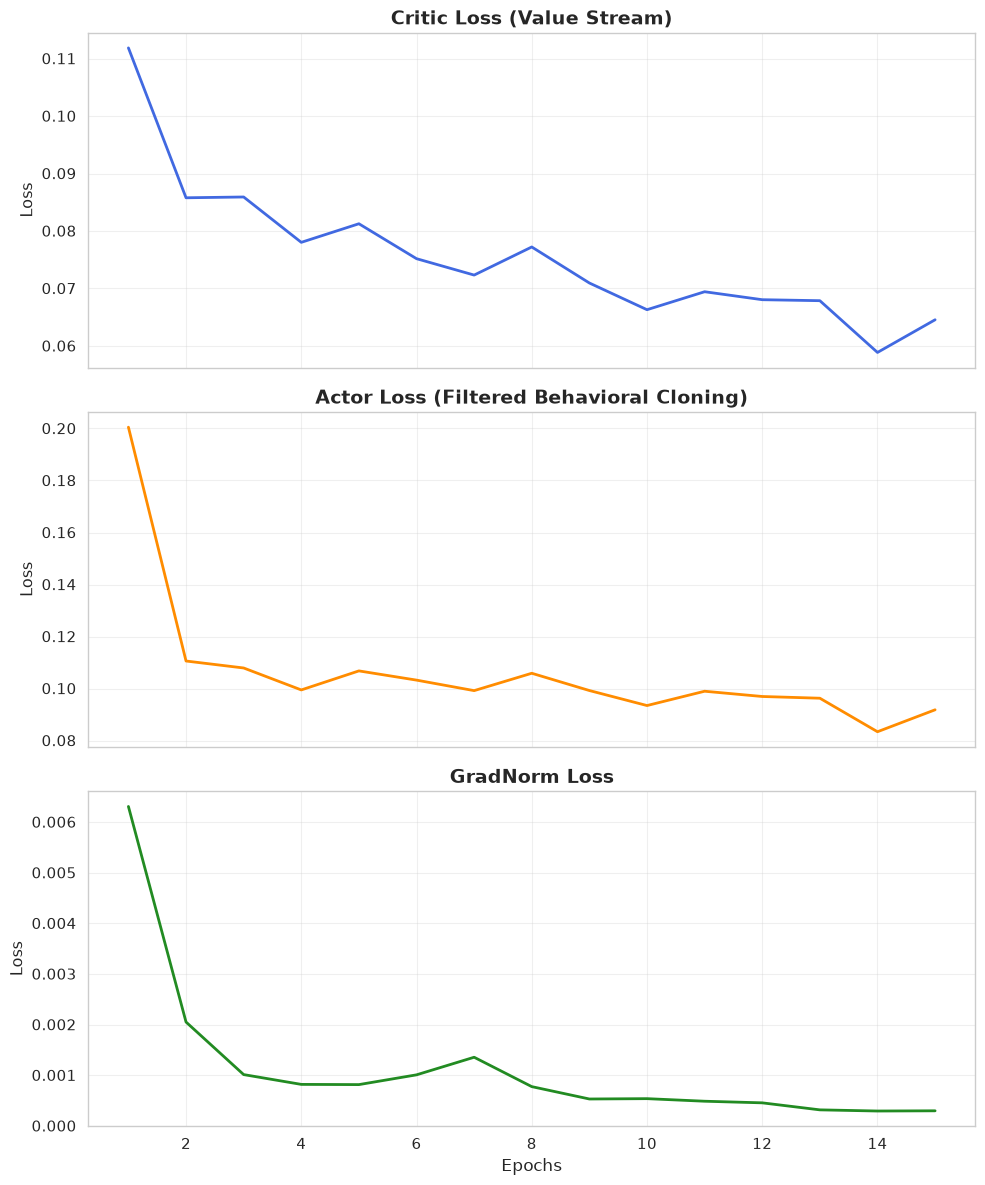

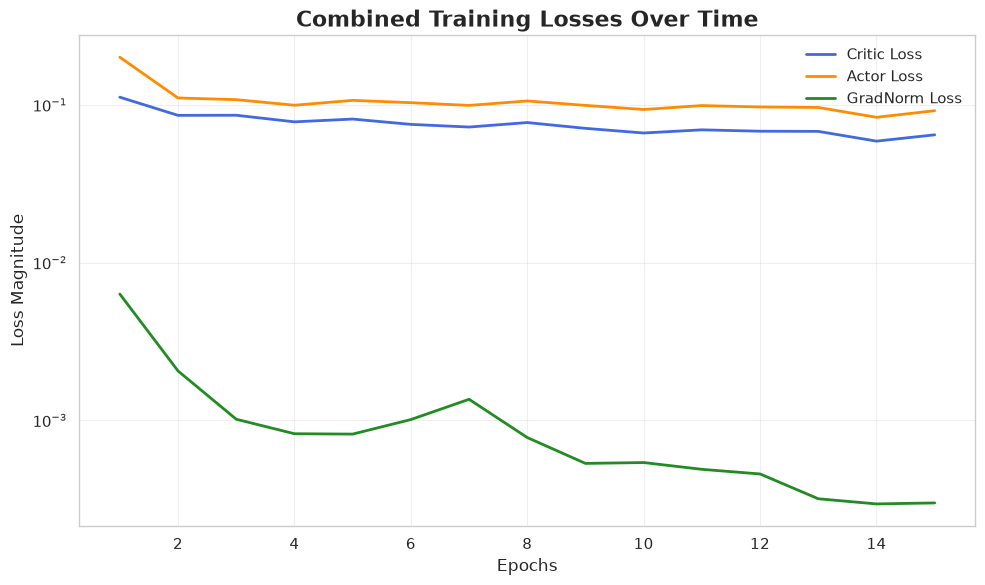

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_training_metrics(training_history):
    """
    Plots the training history using Matplotlib and Seaborn.
    Expects a dictionary with keys: 'critic_loss', 'actor_loss', 'grad_loss'
    """
    # Set Seaborn styling for clean, professional aesthetics
    # sns.set_theme(style="darkgrid", context="notebook")

    # Generate an X-axis for our epochs
    epochs = range(1, len(training_history["critic_loss"]) + 1)

    # Stacked Subplots
    # sharex=True aligns the epochs perfectly across all three plots
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 12), sharex=True)

    # 1. Critic Loss Plot
    sns.lineplot(
        x=epochs,
        y=training_history["critic_loss"],
        ax=axes[0],
        color="royalblue",
        linewidth=2,
    )
    axes[0].set_title("Critic Loss (Value Stream)", fontsize=14, fontweight="bold")
    axes[0].set_ylabel("Loss")

    # 2. Actor Loss Plot
    sns.lineplot(
        x=epochs,
        y=training_history["actor_loss"],
        ax=axes[1],
        color="darkorange",
        linewidth=2,
    )
    axes[1].set_title(
        "Actor Loss (Filtered Behavioral Cloning)", fontsize=14, fontweight="bold"
    )
    axes[1].set_ylabel("Loss")

    # 3. GradNorm Loss Plot
    sns.lineplot(
        x=epochs,
        y=training_history["grad_loss"],
        ax=axes[2],
        color="forestgreen",
        linewidth=2,
    )
    axes[2].set_title("GradNorm Loss", fontsize=14, fontweight="bold")
    axes[2].set_ylabel("Loss")
    axes[2].set_xlabel("Epochs", fontsize=12)

    plt.tight_layout()
    plt.show()

    # Combined Overlay Plot
    plt.figure(figsize=(10, 6))

    sns.lineplot(
        x=epochs,
        y=training_history["critic_loss"],
        label="Critic Loss",
        color="royalblue",
        linewidth=2,
    )
    sns.lineplot(
        x=epochs,
        y=training_history["actor_loss"],
        label="Actor Loss",
        color="darkorange",
        linewidth=2,
    )
    sns.lineplot(
        x=epochs,
        y=training_history["grad_loss"],
        label="GradNorm Loss",
        color="forestgreen",
        linewidth=2,
    )

    plt.title("Combined Training Losses Over Time", fontsize=16, fontweight="bold")
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel("Loss Magnitude", fontsize=12)

    # If one loss is massively larger than the others, uncomment the line below to use a log scale.
    plt.yscale("log")

    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.savefig(
        "./plots/LMUT_MOET_Combined_Training_Losses.pdf",
        format="pdf",
        dpi=1200,
        bbox_inches="tight",
    )
    plt.show()


plot_training_metrics(training_history)

#### Save the Final Surrogate Model


In [32]:
# torch.save(dueling_model.state_dict(), "./model/LMUT_MOET_offline_drl_surrogate.pth")

elapsed_time = time.time() - start_time
print(f"\nOffline Deep RL Training Completed in {elapsed_time / 60:.2f} minutes.")
# print("Model saved to './model/LMUT_MOET_offline_drl_surrogate.pth'.")


Offline Deep RL Training Completed in 0.10 minutes.


## Explainable AI (XRL) Generation


### Local Explanations via SHAP (Step-by-Step Inference)


#### PyTorch Model Wrapper for SHAP


In [33]:
# SHAP requires a model that takes an input tensor and returns a single output tensor.
# Since our Dueling Network returns (Q, V, A), we wrap it to only return the Action stream (A).
class ActionStreamWrapper(nn.Module):
    def __init__(self, dueling_model):
        super(ActionStreamWrapper, self).__init__()
        self.model = dueling_model

    def forward(self, x):
        _, _, A = self.model(x)
        return A


action_model = ActionStreamWrapper(dueling_model).to(device)
action_model.eval()

ActionStreamWrapper(
  (model): DuelingMultiHeadNetwork(
    (shared_layers): Sequential(
      (0): Linear(in_features=46, out_features=256, bias=True)
      (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
      (2): ReLU()
      (3): Linear(in_features=256, out_features=128, bias=True)
      (4): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (5): ReLU()
    )
    (value_stream): Sequential(
      (0): Linear(in_features=128, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=1, bias=True)
    )
    (advantage_stream): Sequential(
      (0): Linear(in_features=128, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=2, bias=True)
    )
  )
)

#### Prepare Background and Test Data


In [34]:
print("Preparing background distributions for SHAP...")

# SHAP calculates marginal contributions by comparing predictions against a "baseline" background.
# We sample 200 random states from our normalized State matrix (S_matrix) as the background.
rng = np.random.default_rng(42)
# no_of_random_states = int(input("Enter the number of random states:"))
# background_indices = rng.choice(S_matrix.shape[0], size=no_of_random_states, replace=False)
background_indices = rng.choice(S_matrix.shape[0], size=200, replace=False)
background_tensor = torch.tensor(S_matrix[background_indices], dtype=torch.float32).to(
    device
)

# Select a few specific test cases to explain (e.g., the first 5 transactions)
# transaction_cases = int(input("Enter the number of transactions:"))
# test_indices = np.arange(transaction_cases)
test_indices = np.arange(5)
test_tensor = torch.tensor(S_matrix[test_indices], dtype=torch.float32).to(device)

print("Preparing background distributions for SHAP completed successfully...")

Preparing background distributions for SHAP...
Preparing background distributions for SHAP completed successfully...


#### Initialize GradientExplainer & Compute SHAP


In [35]:
import shap

print("Initializing SHAP GradientExplainer...")
# GradientExplainer is highly stable for continuous PyTorch networks
explainer = shap.GradientExplainer(action_model, background_tensor)

print("Calculating SHAP values for test instances...")
# shap_values will be a list of arrays: [shap_values_for_action_0, shap_values_for_action_1]
shap_values = explainer.shap_values(test_tensor)

# Ensure the output format matches expectations (List of arrays for each action dimension)
if not isinstance(shap_values, list):
    # Depending on SHAP version, it might return a single tensor (batch, features, actions)
    # We slice it into a list for standard processing: [Price Action, Reorder Action]
    shap_values = [shap_values[:, :, 0], shap_values[:, :, 1]]

print("\nSHAP values successfully computed.")

Initializing SHAP GradientExplainer...
Calculating SHAP values for test instances...

SHAP values successfully computed.


#### Visualizing Local Explanations



Generating Local Explanation for Action: Price per Unit (sold) (Transaction #0)


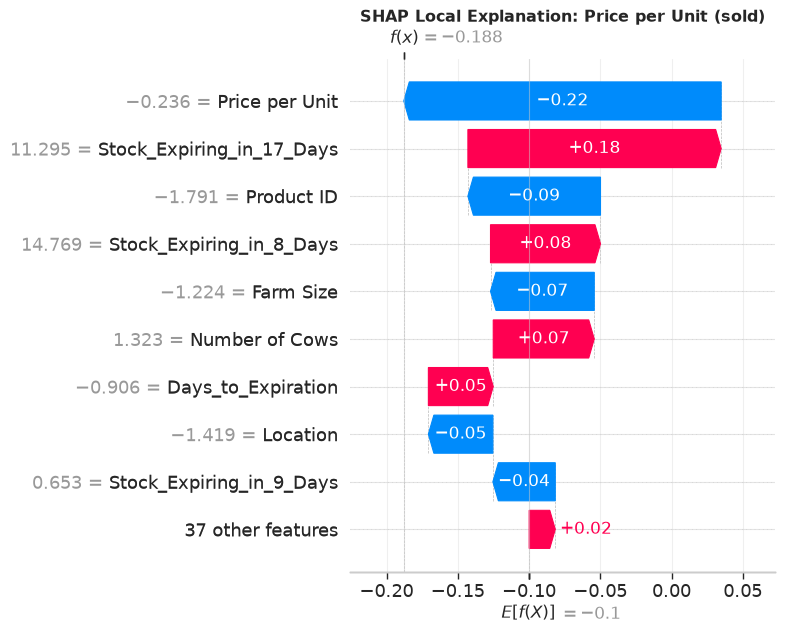


Generating Local Explanation for Action: Reorder Quantity (liters/kg) (Transaction #0)


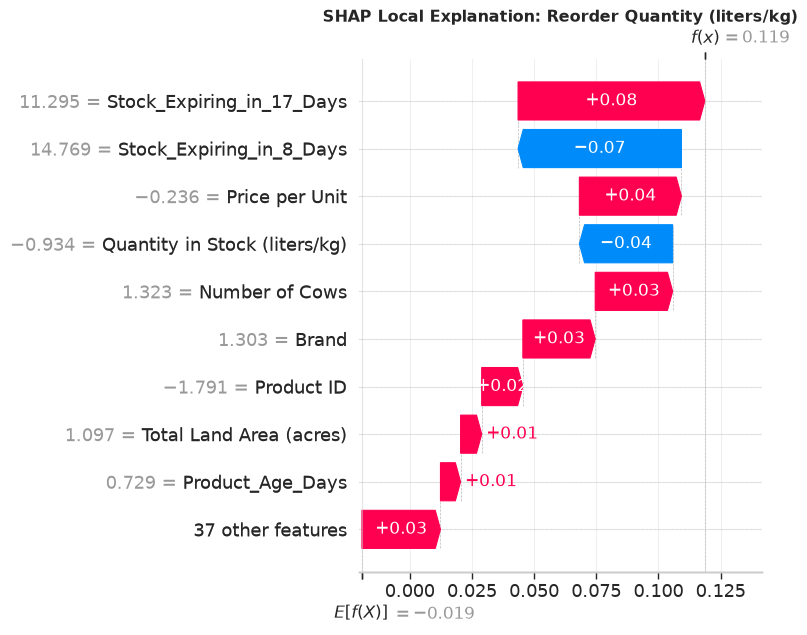

In [36]:
# We want to explain the agent's decision for a specific transaction (e.g., Transaction Index 0)
# INSTANCE_IDX = int(input("Enter the Transaction ID:"))
INSTANCE_IDX = 0

action_names = ["Price per Unit (sold)", "Reorder Quantity (liters/kg)"]

for action_idx, action_name in enumerate(action_names):
    print(
        f"\nGenerating Local Explanation for Action: {action_name} (Transaction #{INSTANCE_IDX})"
    )

    # Extract the base value (expected average output) and the SHAP values for this specific instance
    # GradientExplainer doesn't explicitly store expected_value identically to DeepExplainer, but we can calculate the mean output of the background to use as the base value.
    with torch.no_grad():
        background_outputs = action_model(background_tensor)
        base_value = background_outputs[:, action_idx].mean().item()

    instance_shap_values = shap_values[action_idx][INSTANCE_IDX]
    instance_feature_values = S_matrix[INSTANCE_IDX]

    # Create an Explanation object for the waterfall plot
    explanation = shap.Explanation(
        values=instance_shap_values,
        base_values=base_value,
        data=instance_feature_values,
        feature_names=state_cols,
    )

    # Generate and display the Waterfall Plot
    plt.figure(figsize=(10, 6))
    plt.title(f"SHAP Local Explanation: {action_name}")
    shap.waterfall_plot(explanation, max_display=10, show=False)
    plt.tight_layout()
    plt.show()

#### Summary Profile



Generating Global Summary for 'Price per Unit (sold)' across test batch...


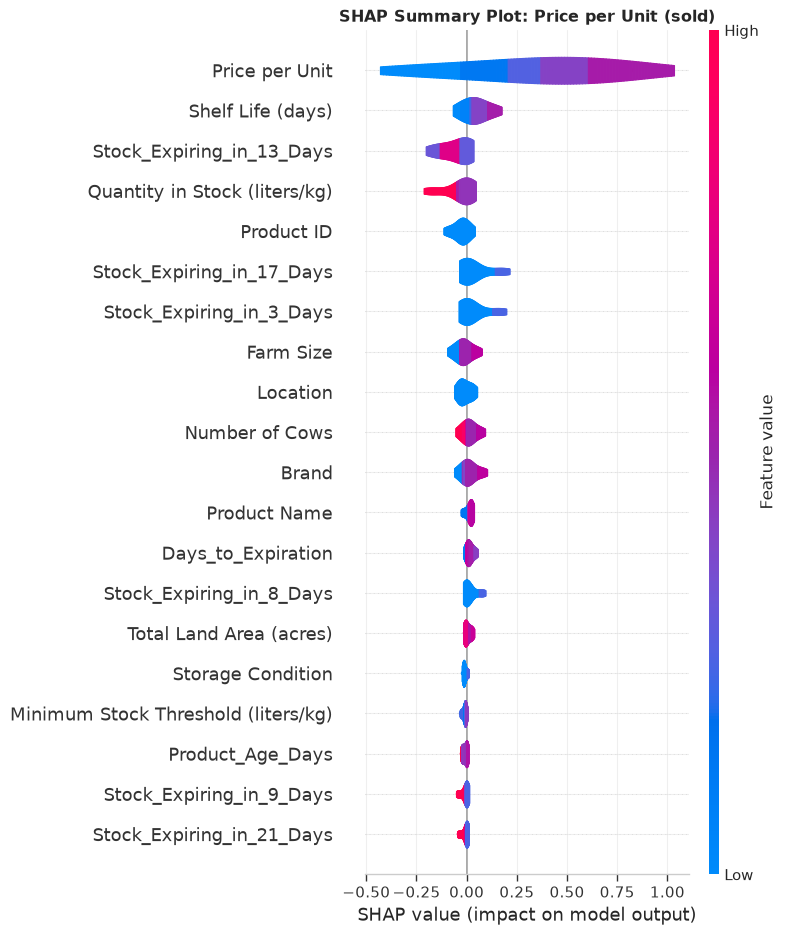

In [37]:
print("\nGenerating Global Summary for 'Price per Unit (sold)' across test batch...")
plt.figure(figsize=(10, 6))
plt.title(f"SHAP Summary Plot: {action_names[0]}")
shap.summary_plot(
    shap_values[0],
    test_tensor.cpu().numpy(),
    feature_names=state_cols,
    show=False,
    plot_type="violin",
)
plt.tight_layout()
plt.show()

### Global Explanations via Symbolic Decision Trees


#### Generate RL Agent Predictions for the Entire Dataset


In [38]:
print("Generating agent predictions to train the surrogate...")
with torch.no_grad():
    # Push the entire scaled state matrix through the Dueling Network
    S_tensor = torch.tensor(S_matrix, dtype=torch.float32).to(device)
    _, _, A_pred_scaled = dueling_model(S_tensor)
    A_pred_scaled = A_pred_scaled.cpu().numpy()

# Inverse transform the actions to get real-world values (Price in INR, Reorder in Liters/kg)
A_pred_real = scaler_A.inverse_transform(A_pred_scaled)
print("Generating agent predictions to train the surrogate successfully...")

Generating agent predictions to train the surrogate...
Generating agent predictions to train the surrogate successfully...


#### Train the Symbolic Surrogate Models


In [39]:
from sklearn.tree import DecisionTreeRegressor

print("Training Surrogate Decision Trees on unscaled features...")
# We use the raw dataframe features so the thresholds are human-readable
X_raw = rl_df_final[state_cols]

# We constrain the tree depth (max_depth=3) to ensure "Compactness" and "Cognitive Load"
# stay manageable for domain experts, avoiding a 20-level deep unreadable mess.
dt_price = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_price.fit(X_raw, A_pred_real[:, 0])

dt_reorder = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_reorder.fit(X_raw, A_pred_real[:, 1])
print("Training Surrogate Decision Trees on unscaled features successfully...")

Training Surrogate Decision Trees on unscaled features...
Training Surrogate Decision Trees on unscaled features successfully...


#### Extract Human-Readable IF-THEN Rules


In [40]:
from sklearn.tree import export_text, plot_tree

print("\n" + "-" * 60)
print("GLOBAL STRATEGY RULES: PRICE PER UNIT (SOLD)")
print("-" * 60)
rules_price = export_text(dt_price, feature_names=list(X_raw.columns))
print(rules_price)

print("\n" + "-" * 60)
print("GLOBAL STRATEGY RULES: REORDER QUANTITY")
print("-" * 60)
rules_reorder = export_text(dt_reorder, feature_names=list(X_raw.columns))
print(rules_reorder)


------------------------------------------------------------
GLOBAL STRATEGY RULES: PRICE PER UNIT (SOLD)
------------------------------------------------------------
|--- Price per Unit <= 54.07
|   |--- Price per Unit <= 33.67
|   |   |--- Price per Unit <= 22.60
|   |   |   |--- value: [17.22]
|   |   |--- Price per Unit >  22.60
|   |   |   |--- value: [27.59]
|   |--- Price per Unit >  33.67
|   |   |--- Price per Unit <= 43.28
|   |   |   |--- value: [38.18]
|   |   |--- Price per Unit >  43.28
|   |   |   |--- value: [49.30]
|--- Price per Unit >  54.07
|   |--- Price per Unit <= 76.54
|   |   |--- Price per Unit <= 64.93
|   |   |   |--- value: [60.49]
|   |   |--- Price per Unit >  64.93
|   |   |   |--- value: [71.60]
|   |--- Price per Unit >  76.54
|   |   |--- Price per Unit <= 87.67
|   |   |   |--- value: [82.90]
|   |   |--- Price per Unit >  87.67
|   |   |   |--- value: [94.06]


------------------------------------------------------------
GLOBAL STRATEGY RULES: REOR

#### Evaluate Surrogate Fidelity ($R^2$ Score)


In [41]:
# Fidelity measures how accurately the simple Decision Tree mimics the complex PyTorch model.
score_price = dt_price.score(X_raw, A_pred_real[:, 0])
score_inv = dt_reorder.score(X_raw, A_pred_real[:, 1])

print("\nSurrogate Fidelity Check (R^2 Score):")
print(f"-> Pricing Strategy Tree Fidelity: {score_price:.4f}")
print(f"-> Reorder Strategy Tree Fidelity: {score_inv:.4f}")

if score_price < 0.70 or score_inv < 0.70:
    print(
        "\n* Note: A lower fidelity score is expected when severely restricting tree depth (max_depth=3)."
    )
    print(
        "  To increase fidelity, increase max_depth, though this will reduce human interpretability."
    )


Surrogate Fidelity Check (R^2 Score):
-> Pricing Strategy Tree Fidelity: 0.9709
-> Reorder Strategy Tree Fidelity: 0.2217

* Note: A lower fidelity score is expected when severely restricting tree depth (max_depth=3).
  To increase fidelity, increase max_depth, though this will reduce human interpretability.


#### Visualizing the Strategy Tree



Generating Decision Tree Visualization for Pricing Strategy...


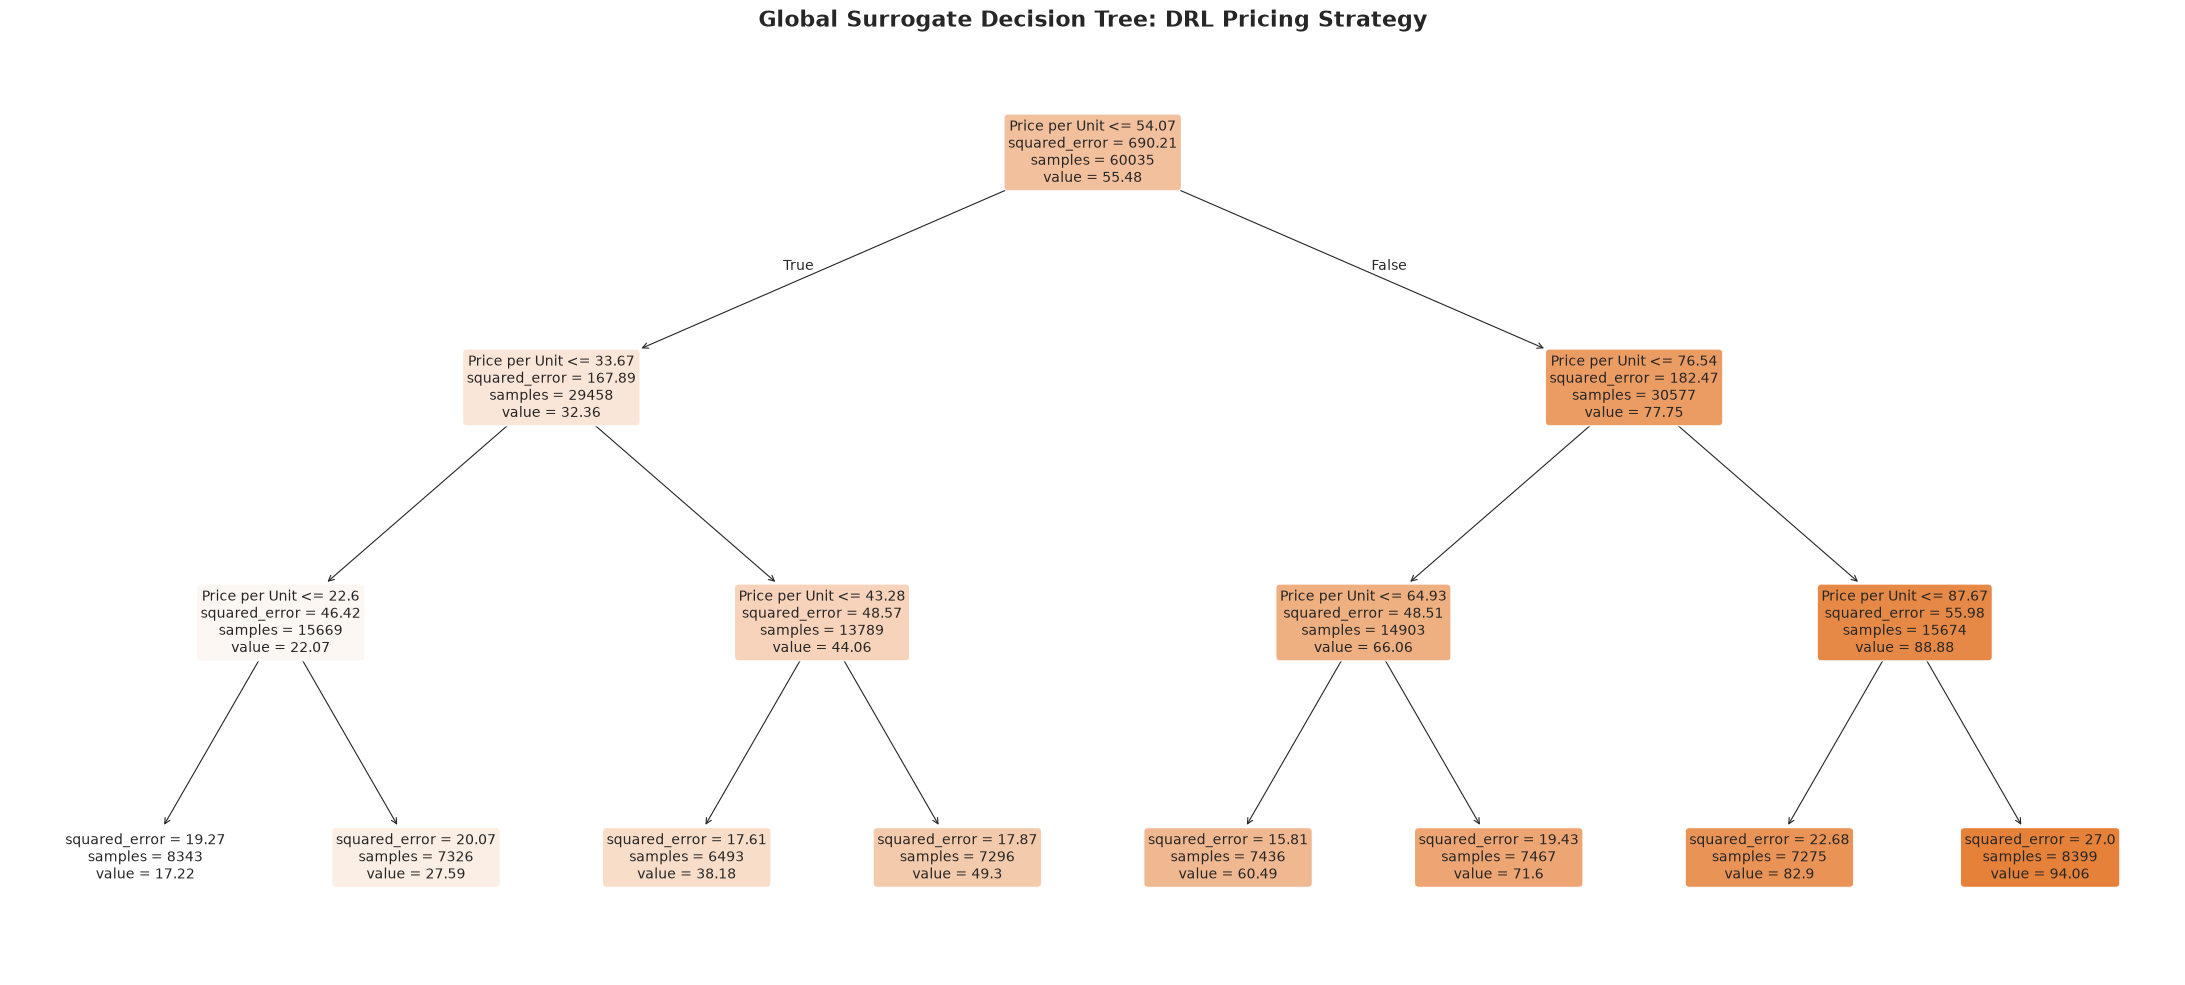

In [42]:
print("\nGenerating Decision Tree Visualization for Pricing Strategy...")
plt.figure(figsize=(22, 10))
plot_tree(
    dt_price,
    feature_names=list(X_raw.columns),
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
)
plt.title("Global Surrogate Decision Tree: DRL Pricing Strategy", fontsize=16)
plt.tight_layout()
plt.show()


Generating Decision Tree Visualization for Reordering Strategy...


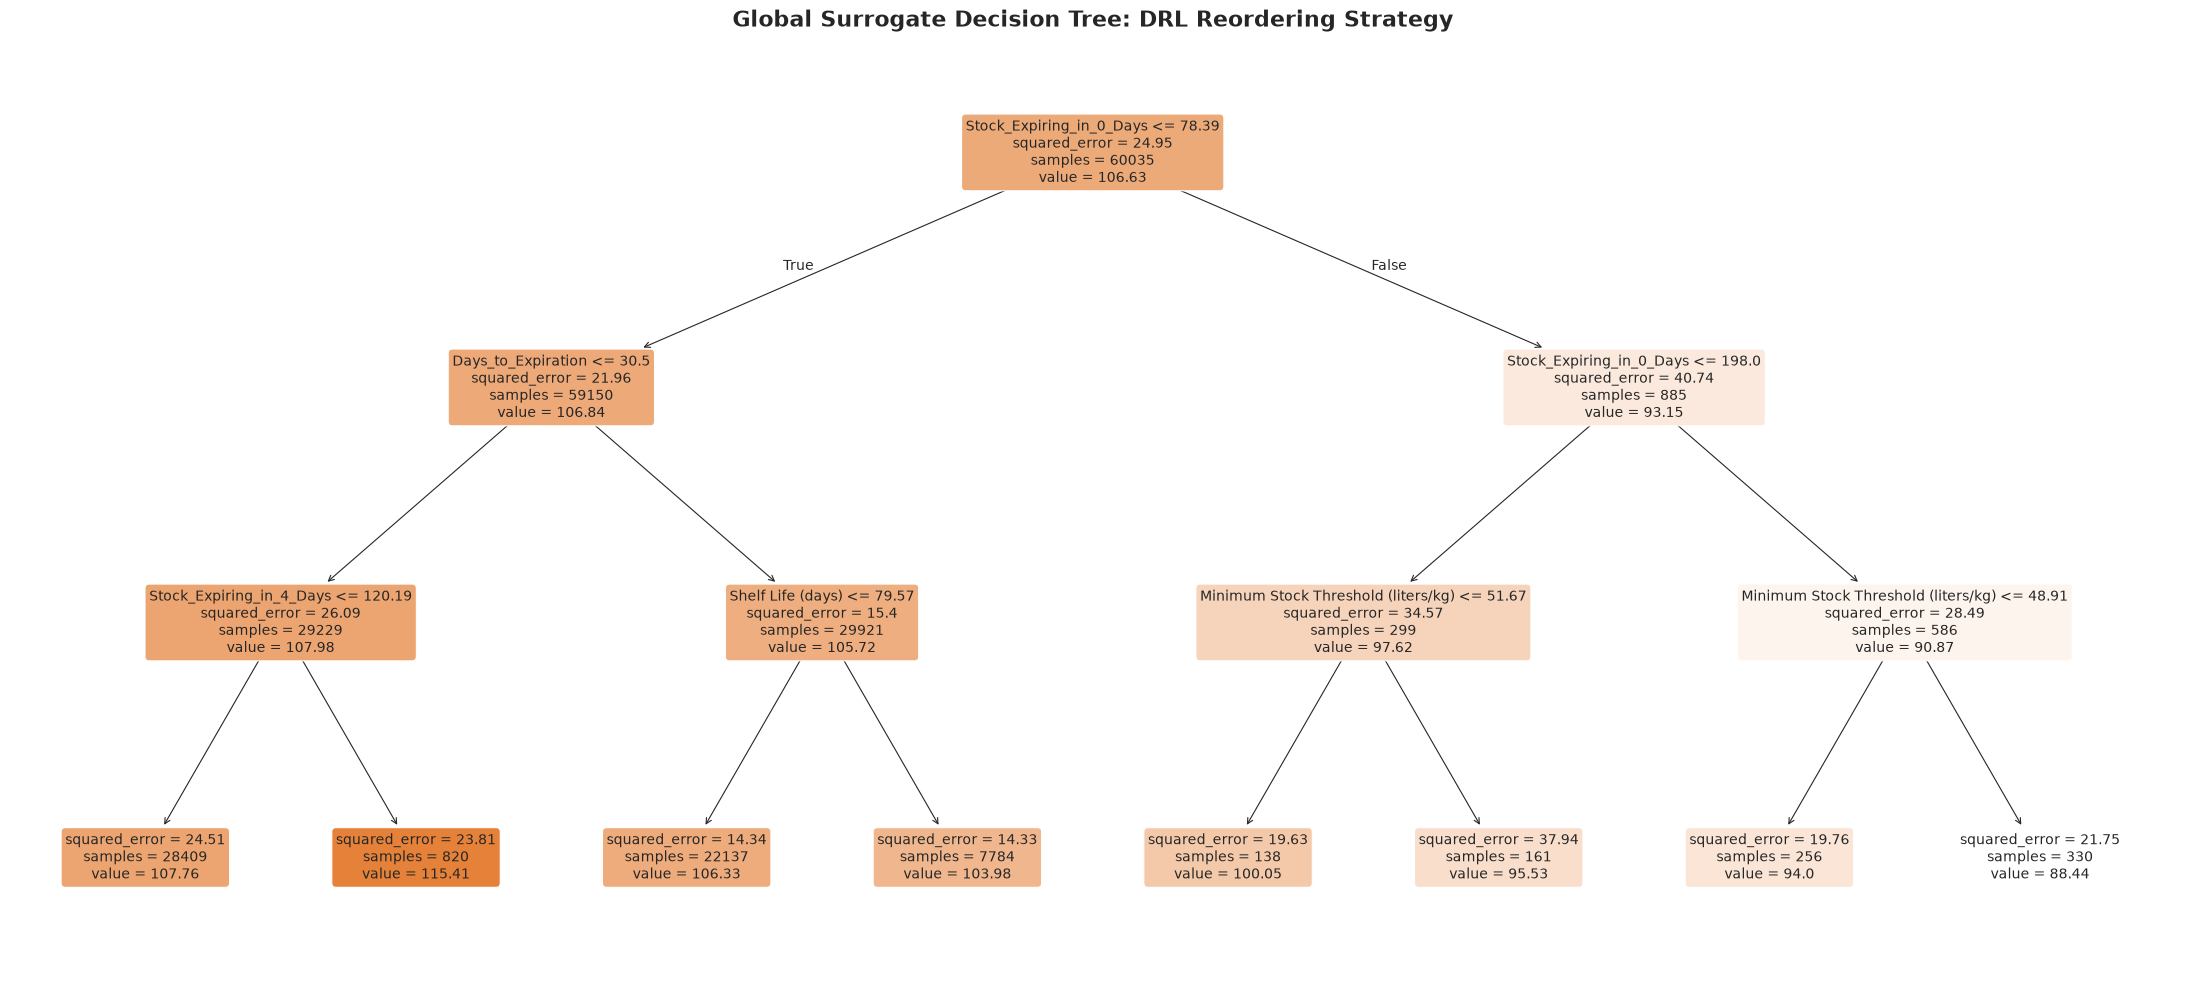

In [43]:
print("\nGenerating Decision Tree Visualization for Reordering Strategy...")
plt.figure(figsize=(22, 10))
plot_tree(
    dt_reorder,
    feature_names=list(X_raw.columns),
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
)
plt.title("Global Surrogate Decision Tree: DRL Reordering Strategy", fontsize=16)
plt.tight_layout()
plt.show()

### Reward Decomposition (Post-Hoc Financial Surrogate)


#### Prepare Data for the Reward Surrogate


In [44]:
print("Preparing State-Action paired data...")
# We use the historical states and the historical actions to teach the surrogate how the environment reacts
X_hist = np.hstack([S_matrix, A_matrix])
# Target variables: The 4 distinct financial sub-rewards calculated in Step 1.3
Y_hist = rl_df_final[
    ["Gross_Profit", "Waste_Penalty", "Holding_Cost", "Stockout_Penalty"]
].values

# We combine the states with the Agent's predicted actions to evaluate what the agent expects to happen when it executes its policy.
X_agent_policy = np.hstack([S_matrix, A_pred_scaled])
feature_names_extended = state_cols + action_cols
print("Preparing State-Action paired data successfully...")

Preparing State-Action paired data...
Preparing State-Action paired data successfully...


#### Train the Multi-Output Reward Surrogate


In [45]:
from sklearn.ensemble import RandomForestRegressor

print("Training Multi-Output Random Forest Surrogate for Reward Decomposition...")
# The Random Forest maps (State + Action) -> Financial Sub-Rewards
reward_surrogate = RandomForestRegressor(
    n_estimators=50, max_depth=10, random_state=42, n_jobs=-1
)
reward_surrogate.fit(X_hist, Y_hist)
print(
    "Training Multi-Output Random Forest Surrogate for Reward Decomposition successfully..."
)

Training Multi-Output Random Forest Surrogate for Reward Decomposition...
Training Multi-Output Random Forest Surrogate for Reward Decomposition successfully...


#### Predict Sub-Rewards for the Agent's Policy


In [46]:
print("Decomposing Agent's Expected Rewards...")
Y_agent_expected = reward_surrogate.predict(X_agent_policy)
print("Decomposing Agent's Expected Rewards successfully...")

Decomposing Agent's Expected Rewards...
Decomposing Agent's Expected Rewards successfully...


#### Visualizing Reward Decomposition for a Specific Transaction


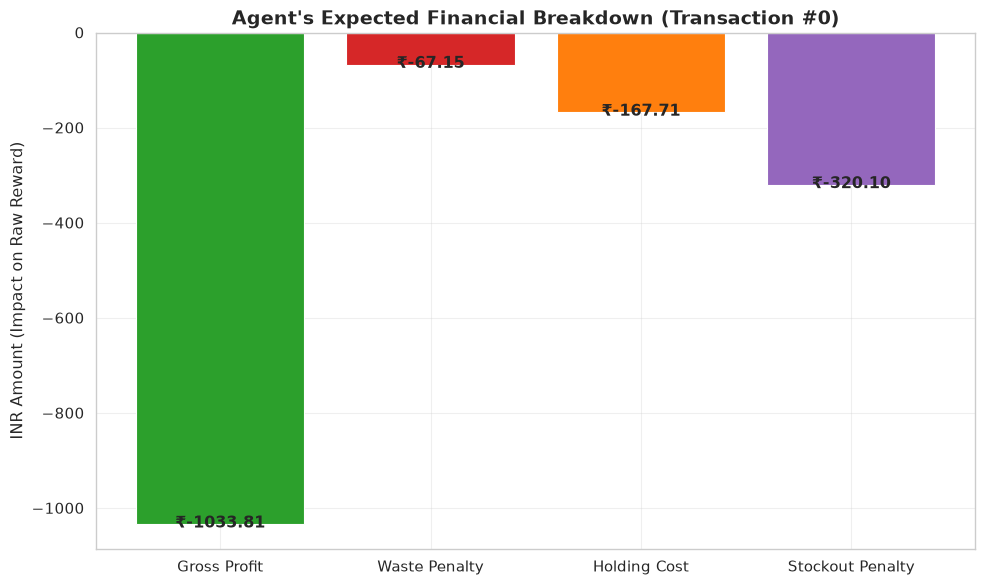

In [47]:
# INSTANCE_IDX = 0
# INSTANCE_IDX = int(input("Enter the Transaction ID:"))
sub_rewards = Y_agent_expected[INSTANCE_IDX]

labels = ["Gross Profit", "Waste Penalty", "Holding Cost", "Stockout Penalty"]
# Gross profit is a positive gain. Penalties are negative impacts to the total reward.
values = [sub_rewards[0], -sub_rewards[1], -sub_rewards[2], -sub_rewards[3]]
colors = ["#2ca02c", "#d62728", "#ff7f0e", "#9467bd"]

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=colors)
plt.axhline(0, color="black", linewidth=1.2)
plt.title(
    f"Agent's Expected Financial Breakdown (Transaction #{INSTANCE_IDX})", fontsize=14
)
plt.ylabel("INR Amount (Impact on Raw Reward)")

# Add text labels on the bars
for bar, v in zip(bars, values):
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + (5 if v > 0 else -15),
        f"₹{v:.2f}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

#### SHAP Analysis: Isolating a Specific Objective (Waste Penalty)



Applying SHAP to explain how the Agent controls the 'Waste Penalty' Objective...


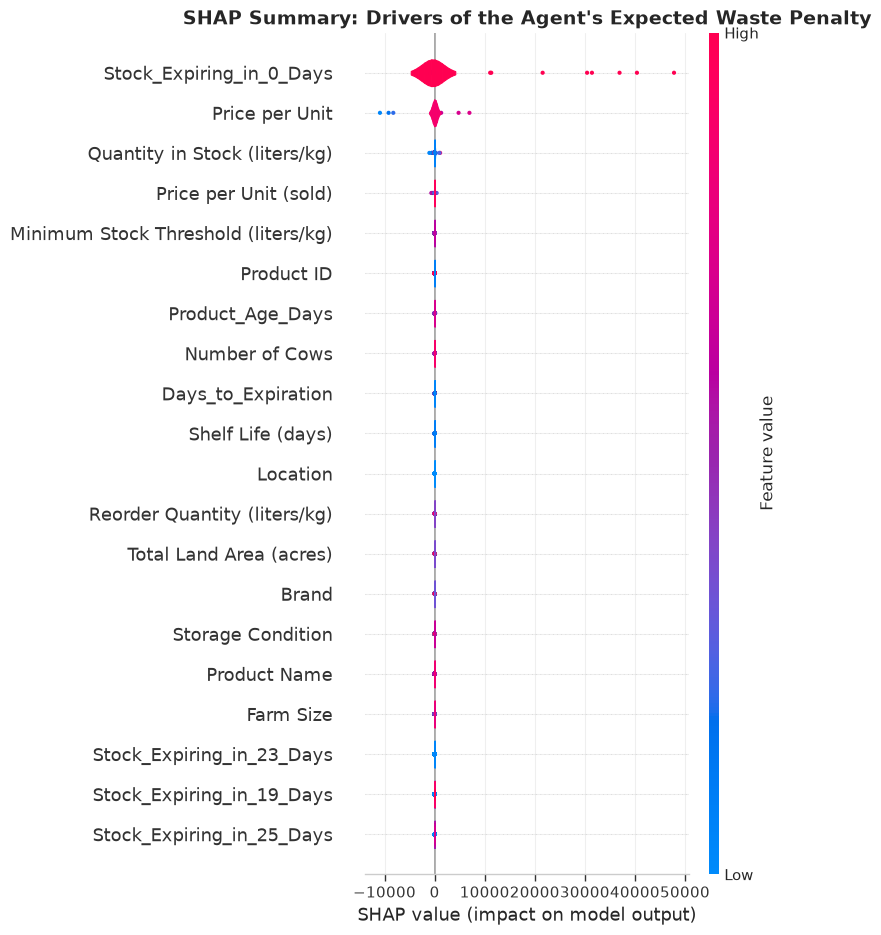

In [48]:
print(
    "\nApplying SHAP to explain how the Agent controls the 'Waste Penalty' Objective..."
)

# Explain the Random Forest model using TreeExplainer
tree_explainer = shap.TreeExplainer(reward_surrogate)

# We explain a subset of 200 instances to save computation time
# no_of_instances = int(input("Enter the number of instances:"))
# X_explain = X_agent_policy[:no_of_instances]
X_explain = X_agent_policy[:200]
shap_values_rf = tree_explainer.shap_values(X_explain)

# Safely extract the SHAP values for the second output (Waste_Penalty)
# based on the SHAP library version installed.
if isinstance(shap_values_rf, list):
    # Returns a list of arrays
    waste_shap_values = shap_values_rf[1]
else:
    # Returns a 3D tensor of shape (samples, features, outputs)
    waste_shap_values = shap_values_rf[:, :, 1]

# Generate and display the summary plot
plt.figure(figsize=(12, 6))
plt.title("SHAP Summary: Drivers of the Agent's Expected Waste Penalty", fontsize=14)
shap.summary_plot(
    waste_shap_values,
    X_explain,
    feature_names=feature_names_extended,
    show=False,
    plot_type="violin",
)
plt.tight_layout()
plt.show()

## Post-Hoc XAI Evaluation & Validation


### Post-Hoc Fidelity Baseline Testing


#### Global Fidelity vs. Interpretability Trade-Off


Evaluating Global Surrogate Fidelity across explanation complexities...


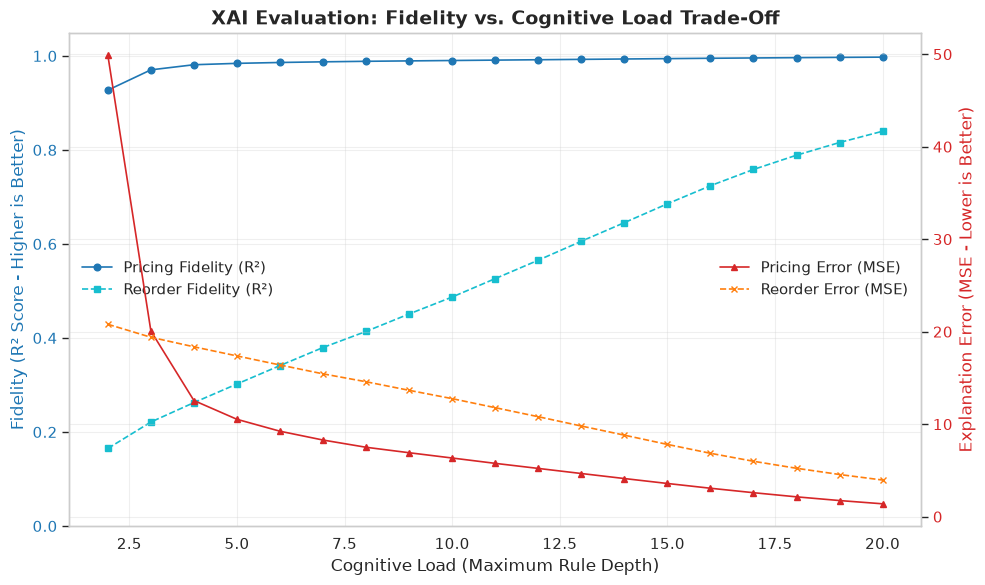

In [49]:
from sklearn.metrics import mean_squared_error, r2_score

print("Evaluating Global Surrogate Fidelity across explanation complexities...")

# We will test Decision Trees of varying depths (from 2 to 15) to quantify the trade-off
# between Cognitive Load (Tree Depth) and Fidelity (R^2 & MSE).
depths = range(2, 21)
fidelity_r2_price = []
fidelity_r2_reorder = []
mse_price = []
mse_reorder = []

X_raw = rl_df_final[state_cols]
# A_pred_real is the DRL agent's actual continuous actions
y_price = A_pred_real[:, 0]
y_reorder = A_pred_real[:, 1]

for d in depths:
    # Train proxies for Pricing
    dt_p = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt_p.fit(X_raw, y_price)
    preds_p = dt_p.predict(X_raw)
    fidelity_r2_price.append(r2_score(y_price, preds_p))
    mse_price.append(mean_squared_error(y_price, preds_p))

    # Train proxies for Reordering
    dt_r = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt_r.fit(X_raw, y_reorder)
    preds_r = dt_r.predict(X_raw)
    fidelity_r2_reorder.append(r2_score(y_reorder, preds_r))
    mse_reorder.append(mean_squared_error(y_reorder, preds_r))

# Plotting the Trade-off Curve
fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = "tab:blue"
color2 = "tab:cyan"
ax1.set_xlabel("Cognitive Load (Maximum Rule Depth)", fontsize=12)
ax1.set_ylabel("Fidelity (R² Score - Higher is Better)", color=color1, fontsize=12)
ax1.plot(
    depths, fidelity_r2_price, marker="o", label="Pricing Fidelity (R²)", color=color1
)
ax1.plot(
    depths,
    fidelity_r2_reorder,
    marker="s",
    linestyle="--",
    label="Reorder Fidelity (R²)",
    color=color2,
)
ax1.tick_params(axis="y", labelcolor=color1)
ax1.set_ylim((0, 1.05))
ax1.legend(loc="center left")
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
color3 = "tab:red"
color4 = "tab:orange"
ax2.set_ylabel("Explanation Error (MSE - Lower is Better)", color=color3, fontsize=12)
ax2.plot(depths, mse_price, marker="^", label="Pricing Error (MSE)", color=color3)
ax2.plot(
    depths,
    mse_reorder,
    marker="x",
    linestyle="--",
    label="Reorder Error (MSE)",
    color=color4,
)
ax2.tick_params(axis="y", labelcolor=color3)
ax2.legend(loc="center right")

plt.title("XAI Evaluation: Fidelity vs. Cognitive Load Trade-Off", fontsize=14)
fig.tight_layout()
plt.savefig(
    "./plots/LMUT_MOET_Fidelity_vs_Cognitive_Load.pdf",
    format="pdf",
    dpi=1200,
    bbox_inches="tight",
)
plt.show()

#### Local Fidelity (SHAP Completeness Axiom)


In [50]:
print("\nEvaluating Local Explanation Fidelity (SHAP Completeness Axiom)...")
# A faithful local explainer must strictly map: sum(SHAP) + Expected_Base_Value == Actual_Model_Output
# If this fails, the local explanation is 'leaking' information and cannot be trusted.

local_fidelity_passed = True
action_names = ["Price per Unit (sold)", "Reorder Quantity (liters/kg)"]

for action_idx, action_name in enumerate(action_names):
    print(f"\nVerifying Completeness for Action: {action_name}")

    # Get baseline expected output across the SHAP background distribution
    with torch.no_grad():
        background_outputs = action_model(background_tensor)
        expected_val = background_outputs[:, action_idx].mean().item()

        # Get actual DRL agent predictions for the specific test instances
        actual_preds = action_model(test_tensor)[:, action_idx].cpu().numpy()

    # Get the sum of the calculated SHAP attributions for the test instances
    shap_sums = shap_values[action_idx].sum(axis=1)

    # Algebraically check Additivity: sum(SHAP) + Base = Actual Output
    for i in range(len(test_indices)):
        explanation_pred = shap_sums[i] + expected_val
        actual_pred = actual_preds[i]
        diff = abs(explanation_pred - actual_pred)

        print(
            f" Instance #{i} | Actual DRL Output: {actual_pred:.4f} | SHAP Explained Output: {explanation_pred:.4f} | Math Diff: {diff:.6f}"
        )

        # Allow a tiny float precision threshold (1e-4) due to 32-bit GPU math
        if diff > 1e-4:
            local_fidelity_passed = False

if local_fidelity_passed:
    print(
        "\n[SUCCESS] Local Fidelity Check Passed: SHAP values strictly reconstruct the DRL agent's local decisions."
    )
else:
    print(
        "\n[WARNING] Local Fidelity Check Failed: SHAP explanations do not sum to the DRL output. The approximation is leaking information."
    )


Evaluating Local Explanation Fidelity (SHAP Completeness Axiom)...

Verifying Completeness for Action: Price per Unit (sold)
 Instance #0 | Actual DRL Output: -0.1457 | SHAP Explained Output: -0.1879 | Math Diff: 0.042144
 Instance #1 | Actual DRL Output: 0.1328 | SHAP Explained Output: 0.0706 | Math Diff: 0.062145
 Instance #2 | Actual DRL Output: 0.6545 | SHAP Explained Output: 0.6269 | Math Diff: 0.027580
 Instance #3 | Actual DRL Output: 0.5175 | SHAP Explained Output: 0.4795 | Math Diff: 0.037986
 Instance #4 | Actual DRL Output: 0.2419 | SHAP Explained Output: 0.2657 | Math Diff: 0.023809

Verifying Completeness for Action: Reorder Quantity (liters/kg)
 Instance #0 | Actual DRL Output: 0.1048 | SHAP Explained Output: 0.1186 | Math Diff: 0.013797
 Instance #1 | Actual DRL Output: 0.1075 | SHAP Explained Output: 0.1317 | Math Diff: 0.024166
 Instance #2 | Actual DRL Output: -0.1019 | SHAP Explained Output: -0.0440 | Math Diff: 0.057869
 Instance #3 | Actual DRL Output: 0.2438 | SH

### Selectivity & Perturbation (PI / Masking)


#### Identify Top and Bottom Features from SHAP


In [51]:
# We use the absolute mean of the SHAP values for Pricing (Action Index 0) from Step 3.1
mean_abs_shap = np.abs(shap_values[0]).mean(axis=0)
sorted_feature_indices = np.argsort(mean_abs_shap)[::-1]

# Extract Top 3 Features
top_3_indices = sorted_feature_indices[:3]
top_3_features = [state_cols[i] for i in top_3_indices]
print(f"Top 3 Features identified by SHAP: \n{top_3_features}\n")

# Extract Bottom 3 Features (for Sanity Check)
bottom_3_indices = sorted_feature_indices[-3:]
bottom_3_features = [state_cols[i] for i in bottom_3_indices]

Top 3 Features identified by SHAP: 
['Price per Unit', 'Shelf Life (days)', 'Stock_Expiring_in_13_Days']



#### Collinearity Check


In [52]:
print("Executing Collinearity Check...")
# We must ensure we don't unfairly penalize the XAI metric if the agent just switches to a highly correlated duplicate feature when the main one is masked.

for feat in top_3_features:
    corrs = []
    for f1, f2, val in collinear_pairs:
        if feat == f1:
            corrs.append(f2)
        elif feat == f2:
            corrs.append(f1)

    if corrs:
        print(
            f" [!] WARNING: '{feat}' is highly correlated with {corrs}. "
            f"Masking it might trigger the agent to use the correlated proxy."
        )
    else:
        print(f" [OK] '{feat}' is independent. No collinearity detected.")

Executing Collinearity Check...
 [!] WARNING: 'Price per Unit' is highly correlated with ['Price per Unit (sold)']. Masking it might trigger the agent to use the correlated proxy.
 [OK] 'Shelf Life (days)' is independent. No collinearity detected.
 [OK] 'Stock_Expiring_in_13_Days' is independent. No collinearity detected.


#### Permutation Importance / Masking Evaluation


In [53]:
print("\nEvaluating Agent Performance Drop (Perturbation Importance)...")


def evaluate_policy_reward(state_tensor):
    """
    Passes the state through the DRL agent to get actions,
    then passes (State, Action) through the Reward Surrogate to get the expected financial return.
    """
    with torch.no_grad():
        _, _, pred_actions = dueling_model(state_tensor)

    # Combine state and actions for the reward surrogate
    X_eval = np.hstack([state_tensor.cpu().numpy(), pred_actions.cpu().numpy()])
    sub_rewards = reward_surrogate.predict(X_eval)

    # Raw Reward = Gross Profit - Waste Penalty - Holding Cost - Stockout Penalty
    raw_rewards = (
        sub_rewards[:, 0] - sub_rewards[:, 1] - sub_rewards[:, 2] - sub_rewards[:, 3]
    )
    return raw_rewards.mean()


# A. Calculate Baseline Expected Reward
baseline_reward = evaluate_policy_reward(test_tensor)
print(f"-> Baseline Expected Reward (Unperturbed): ₹{baseline_reward:.2f}")

# B. Perturb Top 3 Features (Masking)
# We mask the information by setting the scaled feature to 0.0 (the dataset mean)
perturbed_states_top = test_tensor.clone()
for idx in top_3_indices:
    perturbed_states_top[:, idx] = 0.0

degraded_reward_top = evaluate_policy_reward(perturbed_states_top)
drop_pct_top = ((baseline_reward - degraded_reward_top) / abs(baseline_reward)) * 100
print(f"-> Expected Reward (Top 3 Features Masked): ₹{degraded_reward_top:.2f}")
print(f"-> Performance Impact: {drop_pct_top:.2f}% drop")

# C. Perturb Bottom 3 Features (Sanity Check)
print(f"\nSanity Check: Masking Bottom 3 Features \n{bottom_3_features}...")
perturbed_states_bottom = test_tensor.clone()
for idx in bottom_3_indices:
    perturbed_states_bottom[:, idx] = 0.0

degraded_reward_bottom = evaluate_policy_reward(perturbed_states_bottom)
drop_pct_bottom = (
    (baseline_reward - degraded_reward_bottom) / abs(baseline_reward)
) * 100
print(f"-> Expected Reward (Bottom 3 Features Masked): ₹{degraded_reward_bottom:.2f}")
print(f"-> Performance Impact: {drop_pct_bottom:.2f}% drop")


Evaluating Agent Performance Drop (Perturbation Importance)...
-> Baseline Expected Reward (Unperturbed): ₹-2529.56
-> Expected Reward (Top 3 Features Masked): ₹-2006.49
-> Performance Impact: -20.68% drop

Sanity Check: Masking Bottom 3 Features 
['Stock_Expiring_in_26_Days', 'Stock_Expiring_in_14_Days', 'Stock_Expiring_in_23_Days']...
-> Expected Reward (Bottom 3 Features Masked): ₹-2525.19
-> Performance Impact: -0.17% drop


#### Visualization of Performance Degradation


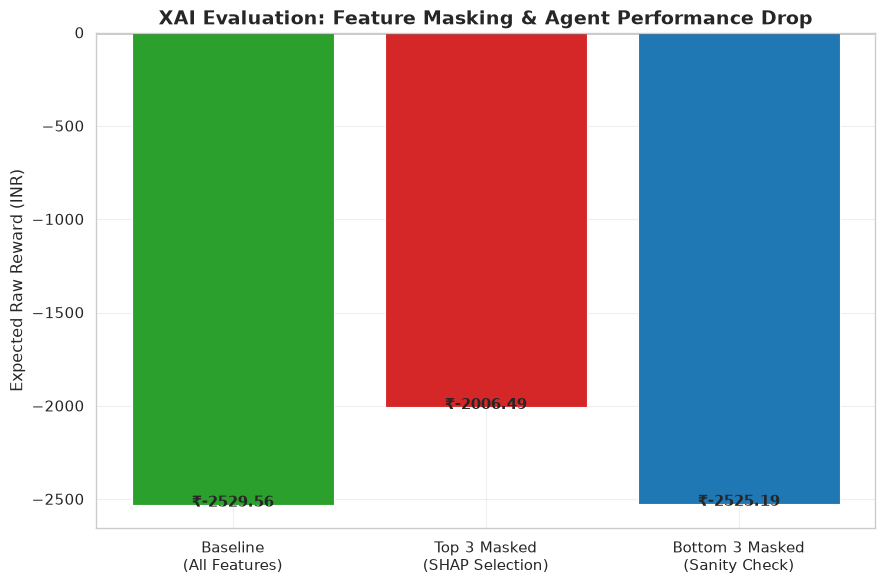

In [54]:
labels = [
    "Baseline\n(All Features)",
    "Top 3 Masked\n(SHAP Selection)",
    "Bottom 3 Masked\n(Sanity Check)",
]
values = [baseline_reward, degraded_reward_top, degraded_reward_bottom]
colors = ["#2ca02c", "#d62728", "#1f77b4"]

plt.figure(figsize=(9, 6))
bars = plt.bar(labels, values, color=colors)
plt.title("XAI Evaluation: Feature Masking & Agent Performance Drop", fontsize=14)
plt.ylabel("Expected Raw Reward (INR)")
plt.axhline(0, color="black", linewidth=1)

for bar, v in zip(bars, values):
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + (10 if v > 0 else -30),
        f"₹{v:.2f}",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=11,
    )

plt.tight_layout()
plt.show()

### Stability & Robustness Profiling (Lipschitz Continuity)


#### Generate Local Perturbations (Noise Injection)


In [55]:
print("Generating 100 near-identical state transitions...")
NUM_SAMPLES = 100
# INSTANCE_IDX = 0
ACTION_IDX = 0  # We evaluate the pricing action

# Extract the base state
base_state = S_matrix[INSTANCE_IDX]

# Inject small Gaussian noise (std=0.01) to simulate tiny environmental fluctuations
# Because S_matrix is StandardScaled, 0.01 represents a 1% standard deviation shift
np.random.seed(42)
noise = np.random.normal(loc=0.0, scale=0.01, size=(NUM_SAMPLES, STATE_DIM))
perturbed_states = base_state + noise

# Ensure the original state is included as the reference at index 0
perturbed_states[0] = base_state
perturbed_tensor = torch.tensor(perturbed_states, dtype=torch.float32).to(device)

Generating 100 near-identical state transitions...


#### Extract SHAP Explanations for Perturbed States


In [56]:
print("Calculating SHAP values for perturbed states...")
# We use the GradientExplainer initialized in Step 3.1
shap_values_perturbed = explainer.shap_values(perturbed_tensor)

# Format handling for different SHAP versions
if isinstance(shap_values_perturbed, list):
    shap_action_perturbed = shap_values_perturbed[ACTION_IDX]
else:
    shap_action_perturbed = shap_values_perturbed[:, :, ACTION_IDX]

# Base SHAP explanation
base_shap = shap_action_perturbed[0]

Calculating SHAP values for perturbed states...


#### Calculate Lipschitz Continuity and Variance


In [57]:
from scipy.spatial.distance import cdist

print("Calculating Lipschitz constants and feature-wise variance...")

# Calculate Euclidean distance between base state and perturbed states (Dx)
# Add a tiny epsilon (1e-9) to prevent division by zero for the base state itself
dx = cdist([base_state], perturbed_states, metric="euclidean")[0] + 1e-9

# Calculate Euclidean distance between base SHAP explanation and perturbed SHAP explanations (De)
de = cdist([base_shap], shap_action_perturbed, metric="euclidean")[0]

# Lipschitz constant is the maximum ratio of change in explanation to change in input
lipschitz_ratios = de / dx
local_lipschitz_constant = np.max(
    lipschitz_ratios[1:]
)  # Ignore index 0 (the base state itself)

# Calculate the variance of the SHAP values for each feature across the 100 samples
shap_variances = np.var(shap_action_perturbed, axis=0)

print("\nStability Metrics:")
print("-" * 60)
print(f"-> Local Lipschitz Constant (L): {local_lipschitz_constant:.4f}")
if local_lipschitz_constant < 5.0:
    print(
        "   [OK] Low Lipschitz constant. The explanations are highly stable and trustworthy."
    )
else:
    print(
        "   [WARNING] High Lipschitz constant. The explanations are fragile to noise."
    )

Calculating Lipschitz constants and feature-wise variance...

Stability Metrics:
------------------------------------------------------------
-> Local Lipschitz Constant (L): 3.9229
   [OK] Low Lipschitz constant. The explanations are highly stable and trustworthy.


#### Visualization of XAI Robustness



Generating Robustness Profile Visualizations...


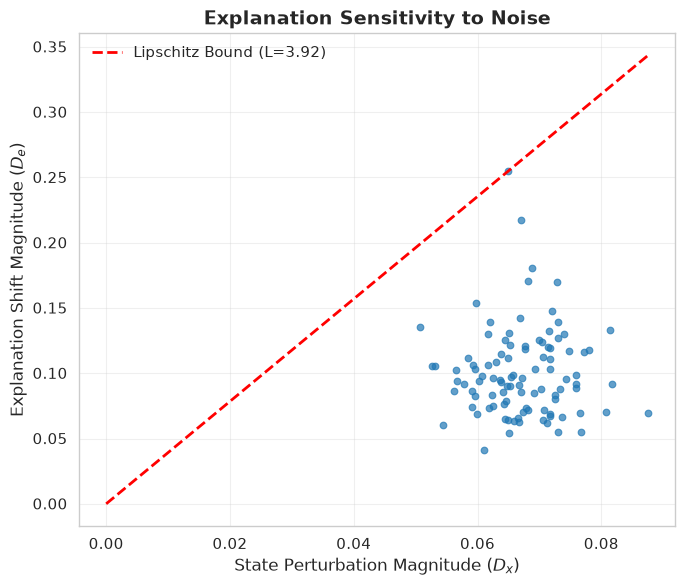

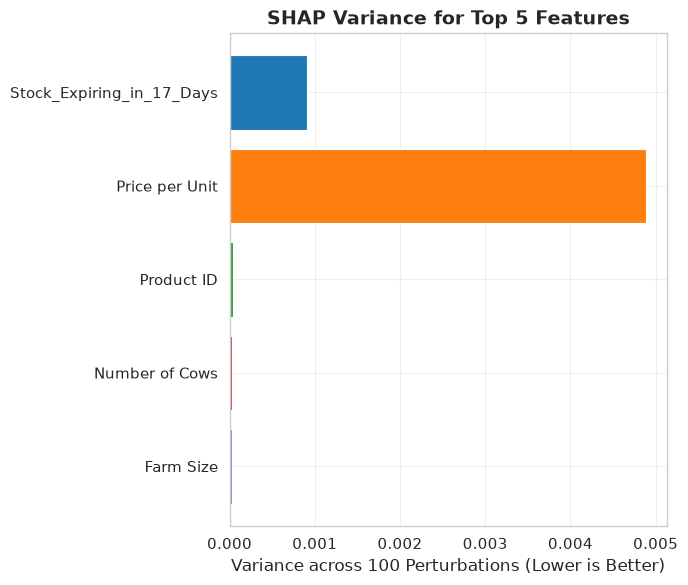

In [58]:
print("\nGenerating Robustness Profile Visualizations...")

# Plot 1: Explanation Sensitivity to Noise
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111)

ax.scatter(dx[1:], de[1:], alpha=0.7, color="#1f77b4")

ax.set_title("Explanation Sensitivity to Noise", fontsize=14)
ax.set_xlabel(r"State Perturbation Magnitude ($D_x$)", fontsize=12)
ax.set_ylabel(r"Explanation Shift Magnitude ($D_e$)", fontsize=12)
ax.grid(alpha=0.3)

# Lipschitz bounding line
x_vals = np.linspace(0, np.max(dx), 100)
y_vals = local_lipschitz_constant * x_vals

ax.plot(
    x_vals,
    y_vals,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Lipschitz Bound (L={local_lipschitz_constant:.2f})",
)

ax.legend()

plt.tight_layout()
plt.savefig(
    "./plots/LMUT_MOET_Explanation_Sensitivity_to_Noise.pdf",
    format="pdf",
    dpi=1200,
    bbox_inches="tight",
)
plt.show()

# Plot 2: SHAP Variance of Top Features
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111)

# Top 5 most important features
top_5_indices = np.argsort(np.abs(base_shap))[::-1][:5]
top_5_features = [state_cols[i] for i in top_5_indices]
top_5_variances = shap_variances[top_5_indices]

ax.barh(
    top_5_features[::-1],
    top_5_variances[::-1],
    color=["#9467bd", "#d62728", "#2ca02c", "#ff7f0e", "#1f77b4"],
)

ax.set_title("SHAP Variance for Top 5 Features", fontsize=14)
ax.set_xlabel(
    "Variance across 100 Perturbations (Lower is Better)",
    fontsize=12,
)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(
    "./plots/LMUT_MOET_SHAP_Variance_Top5_Features.pdf",
    format="pdf",
    dpi=1200,
    bbox_inches="tight",
)
plt.show()

## Architectural Metric Summary


In [59]:
import pandas as pd

LMUT_MOET_data = {
    "Average Reward": f"{A_pred_scaled.mean():.4f}",
    "Policy Loss": f"{training_history['actor_loss'][-1]:.4f}",
    "Value Loss": f"{training_history['critic_loss'][-1]:.4f}",
    "MAE": f"{p_mae:.4f}",
    "RMSE": f"{p_rmse:.4f}",
    "R²": f"{p_r2:.4f}",
    "Pricing Accuracy": f"{p_acc:.2f}%",
    "Reordering Accuracy": f"{r_acc:.2f}%",
    "Overall DRL Accuracy": f"{overall_drl_acc:.2f}%",
    "Training Time": f"{elapsed_time:.2f} sec",
    "Pricing Strategy Tree Fidelity (Depth=3)": f"{score_price * 100:.2f}%",
    "Reorder Strategy Tree Fidelity (Depth=3)": f"{score_inv * 100:.2f}%",
    "Baseline Expected Reward (Unperturbed)": f"₹{baseline_reward:.2f}",
    "Expected Reward (Top 3 Features Masked)": f"₹{degraded_reward_top:.2f}",
    "Expected Reward (Bottom 3 Features Masked):": f"₹{degraded_reward_bottom:.2f}",
    "Performance Impact (Top 3 Features Masked)": f"{drop_pct_top:.2f}%",
    "Performance Impact (Bottom 3 Features Masked)": f"{drop_pct_bottom:.2f}%",
    "Lipschitz Constant": local_lipschitz_constant,
}

LMUT_MOET_df = pd.DataFrame([LMUT_MOET_data], index=["Dueling_DRL"]).T
LMUT_MOET_df.to_csv("./results/LMUT_MOET_df.csv", index=True)
LMUT_MOET_df

,Dueling_DRL
Average Reward,-0.0000
Policy Loss,0.0918
Value Loss,0.0646
MAE,4.1408
RMSE,5.3006
R²,0.9601
Pricing Accuracy,94.66%
Reordering Accuracy,71.32%
Overall DRL Accuracy,82.99%
Training Time,5.79 sec


## Linear Model U-Tree (LMUT)


Linear Model U-Tree (LMUT) for tracking PPO Value Stream $V(s)$. Direct rule-based tracking of how state features scale the expected baseline returns.


### Linear Model U-Tree (LMUT) Class


In [60]:
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.tree import DecisionTreeRegressor


class LinearModelTreeRegressor(BaseEstimator, RegressorMixin):
    """Custom Linear Model U-Tree (LMUT) for continuous value stream tracking.

    Splits the state space structurally, then fits an interpretable
    linear regression model at each leaf node.
    """

    def __init__(self, max_depth=3, min_samples_split=50, alpha=1.0):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.alpha = alpha  # L2 regularization for leaf regressions
        self.structure_tree = None
        self.leaf_models = {}

    def fit(self, X, y):
        # 1. Learn the structural partitions using variance reduction
        self.structure_tree = DecisionTreeRegressor(
            max_depth=self.max_depth,
            min_samples_split=self.min_samples_split,
            random_state=42,
        )
        self.structure_tree.fit(X, y)

        # 2. Identify which leaf ID each sample gets routed into
        leaf_ids = self.structure_tree.apply(X)
        unique_leaves = np.unique(leaf_ids)

        # 3. Fit a localized linear model (Ridge) for each unique partition
        for leaf in unique_leaves:
            mask = leaf_ids == leaf
            X_partition = X[mask]
            y_partition = y[mask]

            # Fit a regularized linear model to capture scaling factors safely
            linear_expert = Ridge(alpha=self.alpha)
            linear_expert.fit(X_partition, y_partition)
            self.leaf_models[leaf] = linear_expert

        return self

    def predict(self, X):
        leaf_ids = self.structure_tree.apply(X)
        predictions = np.zeros(X.shape[0])

        for leaf, model in self.leaf_models.items():
            mask = leaf_ids == leaf
            if np.any(mask):
                predictions[mask] = model.predict(X[mask])

        return predictions

    def export_equations(self, feature_names):
        """Recursively parses the tree structure and prints out the mathematical

        equations assigned to each leaf rule boundary.
        """
        tree_ = self.structure_tree.tree_
        children_left = tree_.children_left
        children_right = tree_.children_right
        feature = tree_.feature
        threshold = tree_.threshold

        def recurse(node_id, current_rules):
            # Check if it's a leaf node
            if children_left[node_id] == -1:
                model = self.leaf_models[node_id]
                rule_string = " AND ".join(current_rules)
                print(f"STRATEGY CONTEXT: IF {rule_string}")
                print(f"   => Expected Return = {model.intercept_:.4f}")

                # Print significant coefficients (> 0.01) to keep rules sparse
                for idx, coef in enumerate(model.coef_):
                    if abs(coef) > 0.01:
                        print(f"       + ({coef:.4f} * {feature_names[idx]})")
                print("-" * 80)
                return

            # Extract split parameter names
            feat_name = feature_names[feature[node_id]]
            thresh = threshold[node_id]

            # Traverse down Left and Right splits
            recurse(
                children_left[node_id],
                current_rules + [f"[{feat_name} <= {thresh:.2f}]"],
            )
            recurse(
                children_right[node_id],
                current_rules + [f"[{feat_name} > {thresh:.2f}]"],
            )

        recurse(0, [])

### Exection and Evaluation Loop


In [61]:
from sklearn.linear_model import Ridge

# 1. Extract the actual scalar State Values V(s) from trained DRL network
print("Extracting baseline returns V(s) from the trained PyTorch network...")
dueling_model.eval()
with torch.no_grad():
    S_tensor = torch.tensor(S_matrix, dtype=torch.float32).to(device)
    _, V_drl_scaled, _ = dueling_model(S_tensor)
    V_drl = V_drl_scaled.cpu().numpy().flatten()

# 2. Train the custom LMUT on unscaled features for human-readable thresholds
# X_raw contains real world values (e.g. true days to expiry, land size, etc.)
X_raw = rl_df_final[state_cols]

print("Fitting the Linear Model Tree to the Value Stream...")
lmut = LinearModelTreeRegressor(max_depth=3, min_samples_split=100)
lmut.fit(X_raw.values, V_drl)

# 3. Print the explicit mathematical formulas found at the leaves
print("\n" + "=" * 80)
print("EXTRACTED LMUT RULES & LINEAR SCALING FACTOR EQUATIONS")
print("=" * 80)
lmut.export_equations(feature_names=state_cols)

# 4. Post-Hoc Fidelity Check
lmut_predictions = lmut.predict(X_raw.values)
fidelity_r2 = r2_score(V_drl, lmut_predictions)
fidelity_mse = mean_squared_error(V_drl, lmut_predictions)

print("\n" + "=" * 80)
print("LMUT FIDELITY METRICS")
print("=" * 80)
print(f"-> Global Explanation Fidelity (R² Score): {fidelity_r2:.4f}")
print(f"-> Explanation Mapping Error   (MSE):      {fidelity_mse:.4f}")

Extracting baseline returns V(s) from the trained PyTorch network...
Fitting the Linear Model Tree to the Value Stream...

EXTRACTED LMUT RULES & LINEAR SCALING FACTOR EQUATIONS
STRATEGY CONTEXT: IF [Price per Unit <= 42.79] AND [Stock_Expiring_in_0_Days <= 69.27] AND [Price per Unit <= 28.32]
   => Expected Return = 0.4519
--------------------------------------------------------------------------------
STRATEGY CONTEXT: IF [Price per Unit <= 42.79] AND [Stock_Expiring_in_0_Days <= 69.27] AND [Price per Unit > 28.32]
   => Expected Return = 0.5629
       + (-0.0102 * Price per Unit)
--------------------------------------------------------------------------------
STRATEGY CONTEXT: IF [Price per Unit <= 42.79] AND [Stock_Expiring_in_0_Days > 69.27] AND [Stock_Expiring_in_0_Days <= 208.63]
   => Expected Return = 0.4827
       + (-0.0151 * Price per Unit)
       + (0.0586 * Stock_Expiring_in_9_Days)
--------------------------------------------------------------------------------
STRATEGY 

## Mixture of Expert Trees (MOET)


Mixture of Expert Trees (MOET) for Global CART Surrogate to resolve perpendicular split limitations by creating oblique decision boundaries for supply constraints


### Mixture of Expert Trees (MOET) Class


In [62]:
from sklearn.cluster import KMeans


class HardMixtureOfExpertTrees(BaseEstimator, RegressorMixin):
    """
    Implementation of the MOET (Mixture of Expert Trees - Hard Routing) architecture.
    Uses a generalized linear model (Logistic Regression) as a gating function to create
    oblique decision boundaries, routing inputs to specialized Decision Tree experts.
    """

    def __init__(self, n_experts=3, max_tree_depth=3, random_state=42):
        self.n_experts = n_experts
        self.max_tree_depth = max_tree_depth
        self.random_state = random_state

        # The Gating Function (Linear Model for Oblique Splits)
        # multi_class parameter removed for compatibility with scikit-learn >= 1.5
        self.gating_network = LogisticRegression(
            solver="lbfgs", max_iter=1000, random_state=self.random_state
        )

        # The Localized Experts (Standard Axis-Aligned Trees)
        self.experts = {
            k: DecisionTreeRegressor(
                max_depth=self.max_tree_depth, random_state=self.random_state
            )
            for k in range(self.n_experts)
        }

    def fit(self, X, y):
        # 1. Latent Region Discovery
        # n_init="auto" added to prevent warnings in newer scikit-learn versions
        clusterer = KMeans(
            n_clusters=self.n_experts, random_state=self.random_state, n_init="auto"
        )
        expert_assignments = clusterer.fit_predict(X)

        # 2. Train the Gating Function (Generalized Linear Model)
        self.gating_network.fit(X, expert_assignments)

        # 3. Train the Local Experts
        for k in range(self.n_experts):
            mask = expert_assignments == k
            if np.sum(mask) > 0:
                self.experts[k].fit(X[mask], y[mask])
            else:
                self.experts[k].fit(X, y)

        return self

    def predict(self, X):
        expert_routes = self.gating_network.predict(X)
        predictions = np.zeros(X.shape[0])

        for k in range(self.n_experts):
            mask = expert_routes == k
            if np.any(mask):
                predictions[mask] = self.experts[k].predict(X[mask])

        return predictions

    def export_oblique_rules(self, feature_names):
        """
        Decomposes the MOET model into a set of logical rules, translating both
        the linear gating boundaries and the localized decision trees.
        """
        classes = self.gating_network.classes_
        coefs = self.gating_network.coef_
        intercepts = self.gating_network.intercept_

        print(f"MOET ARCHITECTURE: {self.n_experts} EXPERTS DETECTED")
        print("=" * 80)

        for idx, k in enumerate(classes):
            print(f"\n[EXPERT {k} ROUTING GATE] - Oblique Decision Boundary:")

            equation_terms = [f"{intercepts[idx]:.4f}"]
            for feat_idx, weight in enumerate(coefs[idx]):
                if abs(weight) > 0.05:
                    sign = "+" if weight > 0 else "-"
                    equation_terms.append(
                        f"{sign} {abs(weight):.4f}*{feature_names[feat_idx]}"
                    )

            print(" IF ( " + " ".join(equation_terms) + " ) is MAX")
            print("-" * 40)
            print(f"[EXPERT {k} POLICY LOGIC]:")

            tree_rules = export_text(self.experts[k], feature_names=feature_names)
            print(tree_rules)
            print("=" * 80)

### Exection and Evaluation Loop


In [63]:
from sklearn.linear_model import LogisticRegression

# 1. Prepare the data (Using X_raw from Phase 3 and A_pred_real from the DRL agent)
print("Initializing MOET Global Surrogate for Agent's Pricing Actions...")
X_raw_vals = X_raw.values
y_price_actions = A_pred_real[:, 0]  # Agent's continuous pricing predictions

# 2. Train the Mixture of Expert Trees
moeth_surrogate = HardMixtureOfExpertTrees(n_experts=3, max_tree_depth=3)
moeth_surrogate.fit(X_raw_vals, y_price_actions)

# 3. Export the Oblique & Axis-Aligned Rules
moeth_surrogate.export_oblique_rules(feature_names=state_cols)

# 4. Post-Hoc Fidelity Evaluation
moeth_predictions = moeth_surrogate.predict(X_raw_vals)
moeth_r2 = r2_score(y_price_actions, moeth_predictions)
moeth_mse = mean_squared_error(y_price_actions, moeth_predictions)

print("\n" + "=" * 80)
print("MOETh FIDELITY METRICS vs STANDARD CART")
print("=" * 80)
print(f"-> MOETh Global Fidelity (R² Score): {moeth_r2:.4f}")
print(f"-> MOETh Mapping Error   (MSE):      {moeth_mse:.4f}")
print(f"-> Standard CART Fidelity (R²):      {score_price:.4f} (For comparison)")

Initializing MOET Global Surrogate for Agent's Pricing Actions...
MOET ARCHITECTURE: 3 EXPERTS DETECTED

[EXPERT 0 ROUTING GATE] - Oblique Decision Boundary:
 IF ( 0.0010 ) is MAX
----------------------------------------
[EXPERT 0 POLICY LOGIC]:
|--- Price per Unit <= 54.11
|   |--- Price per Unit <= 33.67
|   |   |--- Price per Unit <= 22.60
|   |   |   |--- value: [17.19]
|   |   |--- Price per Unit >  22.60
|   |   |   |--- value: [27.57]
|   |--- Price per Unit >  33.67
|   |   |--- Price per Unit <= 43.28
|   |   |   |--- value: [38.16]
|   |   |--- Price per Unit >  43.28
|   |   |   |--- value: [49.32]
|--- Price per Unit >  54.11
|   |--- Price per Unit <= 76.54
|   |   |--- Price per Unit <= 64.93
|   |   |   |--- value: [60.51]
|   |   |--- Price per Unit >  64.93
|   |   |   |--- value: [71.61]
|   |--- Price per Unit >  76.54
|   |   |--- Price per Unit <= 87.67
|   |   |   |--- value: [82.92]
|   |   |--- Price per Unit >  87.67
|   |   |   |--- value: [94.09]


[EXPERT 1 

In [64]:
# 1. Prepare the data (Using X_raw from Phase 3 and A_pred_real from the DRL agent)
print("Initializing MOËTh Global Surrogate for Agent's Pricing Actions...")
X_raw_vals = X_raw.values
y_reorder_actions = A_pred_real[:, 1]  # Agent's continuous reorder predictions

# 2. Train the Mixture of Expert Trees
moeth_surrogate = HardMixtureOfExpertTrees(n_experts=3, max_tree_depth=3)
moeth_surrogate.fit(X_raw_vals, y_reorder_actions)

# 3. Export the Oblique & Axis-Aligned Rules
moeth_surrogate.export_oblique_rules(feature_names=state_cols)

# 4. Post-Hoc Fidelity Evaluation
moeth_predictions = moeth_surrogate.predict(X_raw_vals)
moeth_r2 = r2_score(y_reorder_actions, moeth_predictions)
moeth_mse = mean_squared_error(y_reorder_actions, moeth_predictions)

print("\n" + "=" * 80)
print("MOETh FIDELITY METRICS vs STANDARD CART")
print("=" * 80)
print(f"-> MOETh Global Fidelity (R² Score): {moeth_r2:.4f}")
print(f"-> MOETh Mapping Error   (MSE):      {moeth_mse:.4f}")
print(f"-> Standard CART Fidelity (R²):      {score_inv:.4f} (For comparison)")

Initializing MOËTh Global Surrogate for Agent's Pricing Actions...
MOET ARCHITECTURE: 3 EXPERTS DETECTED

[EXPERT 0 ROUTING GATE] - Oblique Decision Boundary:
 IF ( 0.0010 ) is MAX
----------------------------------------
[EXPERT 0 POLICY LOGIC]:
|--- Stock_Expiring_in_0_Days <= 78.39
|   |--- Days_to_Expiration <= 30.50
|   |   |--- Stock_Expiring_in_4_Days <= 120.19
|   |   |   |--- value: [107.76]
|   |   |--- Stock_Expiring_in_4_Days >  120.19
|   |   |   |--- value: [115.68]
|   |--- Days_to_Expiration >  30.50
|   |   |--- Shelf Life (days) <= 79.57
|   |   |   |--- value: [106.29]
|   |   |--- Shelf Life (days) >  79.57
|   |   |   |--- value: [103.97]
|--- Stock_Expiring_in_0_Days >  78.39
|   |--- Stock_Expiring_in_0_Days <= 198.00
|   |   |--- Minimum Stock Threshold (liters/kg) <= 51.67
|   |   |   |--- value: [100.05]
|   |   |--- Minimum Stock Threshold (liters/kg) >  51.67
|   |   |   |--- value: [95.53]
|   |--- Stock_Expiring_in_0_Days >  198.00
|   |   |--- Minimum Sto

## Symbolic Deep Reinforcement Learning (SDRL)


Symbolic Deep RL (SDRL) for Multi-Head Advantage Stream to separate high-level multi-objective constraints from low-level continuous action spaces.


### High-Level Symbolic Planner (Meta-Controller)


In [65]:
class SymbolicSupplyChainPlanner:
    """
    The High-Level Symbolic Meta-Controller.
    Evaluates real-world state variables using propositional logic to determine
    the active macro-objective (Sub-Goal).
    """

    def __init__(self):
        # Define the discrete sub-goals the DRL network will specialize in
        self.goals = {
            0: "CLEARANCE_MODE",  # Objective: Minimize incoming waste penalty
            1: "RESTOCK_MODE",  # Objective: Prevent imminent stockouts
            2: "PROFIT_MODE",  # Objective: Maximize standard gross margin
        }

    def evaluate_state(self, state_raw_dict):
        """
        Takes human-readable unscaled features to evaluate constraints.
        Returns the Goal ID and the symbolic logic trace (The Explanation).
        """
        # Extract interpretable variables
        expiring_stock = state_raw_dict.get(
            "Stock_Expiring_in_0_Days", 0
        ) + state_raw_dict.get("Stock_Expiring_in_1_Days", 0)
        current_stock = state_raw_dict.get("Quantity in Stock (liters/kg)", 0)
        min_threshold = state_raw_dict.get("Minimum Stock Threshold (liters/kg)", 0)

        # Predicate 1: Is there an imminent critical waste threat?
        if expiring_stock > (0.15 * current_stock) and expiring_stock > 50:
            logic_trace = (
                f"High Perishability Threat Detected: {expiring_stock:.1f} units expiring in < 48 hours. "
                f"Constraint Priority overrides to Waste Minimization."
            )
            return 0, logic_trace  # CLEARANCE_MODE

        # Predicate 2: Is the inventory critically low?
        elif current_stock < min_threshold:
            logic_trace = (
                f"Stockout Threat Detected: Current stock ({current_stock:.1f}) is below "
                f"minimum threshold ({min_threshold:.1f}). Constraint Priority overrides to Replenishment."
            )
            return 1, logic_trace  # RESTOCK_MODE

        # Predicate 3: Default stable operating conditions
        else:
            logic_trace = (
                f"Stable Environment: Stock is healthy ({current_stock:.1f}) and immediate waste is low. "
                f"Constraint Priority defaults to Margin Maximization."
            )
            return 2, logic_trace  # PROFIT_MODE

### Low-Level DRL: Goal-Conditioned Multi-Head Dueling Network


In [66]:
class SDRLMultiHeadNetwork(nn.Module):
    """
    The Low-Level Goal-Conditioned Dueling Network.
    Contains a shared representation layer and a Value stream, but branches into
    multiple separate Advantage streams based on the Symbolic Planner's chosen goal.
    """

    def __init__(self, state_dim, action_dim, num_goals=3):
        super(SDRLMultiHeadNetwork, self).__init__()

        self.num_goals = num_goals

        # Shared State Representation Encoder
        self.shared_layers = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
        )

        # Unified State Value Stream V(s)
        self.value_stream = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1)
        )

        # Multi-Head Advantage Streams A(s,a|g)
        # Instead of one network trying to balance clearance pricing vs profit pricing,
        # we give each symbolic goal its own dedicated neural pathway to solve continuous math.
        self.advantage_streams = nn.ModuleList(
            [
                nn.Sequential(nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, action_dim))
                for _ in range(self.num_goals)
            ]
        )

    def forward(self, state_scaled, goal_idx):
        """
        Forward pass conditioned on the discrete goal selected by the symbolic planner.
        """
        # 1. Base perception
        shared_features = self.shared_layers(state_scaled)

        # 2. State value
        V = self.value_stream(shared_features)

        # 3. Task-specific Action Advantage
        # We only activate the specific advantage head dictated by the symbolic planner
        A = self.advantage_streams[goal_idx](shared_features)

        # 4. Recombination (Dueling Architecture)
        Q = V + (A - A.mean(dim=1, keepdim=True))

        return Q, V, A

### SDRL Orchestrator and Execution Loop


In [67]:
class SDRLAgentWrapper:
    """
    Wraps the Symbolic Planner and PyTorch DRL model into a single transparent entity.
    """

    def __init__(self, dnn_model, symbolic_planner, state_cols, scaler_A):
        self.dnn_model = dnn_model
        self.symbolic_planner = symbolic_planner
        self.state_cols = state_cols
        self.scaler_A = scaler_A
        self.device = next(dnn_model.parameters()).device

    def act_and_explain(self, raw_state_array, scaled_state_array):
        # Map raw numpy array to dictionary for symbolic logic parsing
        state_dict = {col: val for col, val in zip(self.state_cols, raw_state_array)}

        # 1. High-Level Symbolic Inference
        goal_idx, explanation_trace = self.symbolic_planner.evaluate_state(state_dict)
        goal_name = self.symbolic_planner.goals[goal_idx]

        # 2. Low-Level Continuous Inference
        self.dnn_model.eval()
        with torch.no_grad():
            state_tensor = (
                torch.tensor(scaled_state_array, dtype=torch.float32)
                .unsqueeze(0)
                .to(self.device)
            )
            Q, _, _ = self.dnn_model(state_tensor, goal_idx)

            # Extract and inverse transform continuous actions
            scaled_actions = Q.cpu().numpy()
            real_actions = self.scaler_A.inverse_transform(scaled_actions)[0]

        # Compile Interpretability Output
        output = {
            "Active_Constraint": goal_name,
            "Symbolic_Explanation": explanation_trace,
            "Predicted_Price": real_actions[0],
            "Predicted_Reorder": real_actions[1],
        }
        return output

In [68]:
print("Initializing Hierarchical SDRL Framework...")
# Instantiate components (Assuming STATE_DIM=46, ACTION_DIM=2 from previous phases)
planner = SymbolicSupplyChainPlanner()
sdrl_model = SDRLMultiHeadNetwork(state_dim=STATE_DIM, action_dim=ACTION_DIM).to(device)

# Wrap into the orchestrator
sdrl_agent = SDRLAgentWrapper(sdrl_model, planner, state_cols, scaler_A)

# Simulate three distinct scenarios from the dataset
print("\n" + "=" * 80)
print("SDRL INFERENCE & EXPLANATION TRACES")
print("=" * 80)

# Scenario A: High Spoilage Risk
test_raw_A = S_raw[0].copy()
test_raw_A[state_cols.index("Stock_Expiring_in_0_Days")] = (
    300  # Inject high imminent waste
)
result_A = sdrl_agent.act_and_explain(test_raw_A, S_matrix[0])

print(f"\n[SCENARIO A] - {result_A['Active_Constraint']}")
print(f"REASONING: {result_A['Symbolic_Explanation']}")
print(
    f"ACTION DECISION: Price=₹{result_A['Predicted_Price']:.2f}, Reorder={result_A['Predicted_Reorder']:.2f} liters"
)

# Scenario B: Stockout Danger
test_raw_B = S_raw[1].copy()
test_raw_B[state_cols.index("Quantity in Stock (liters/kg)")] = 10
test_raw_B[state_cols.index("Minimum Stock Threshold (liters/kg)")] = 50
result_B = sdrl_agent.act_and_explain(test_raw_B, S_matrix[1])

print(f"\n[SCENARIO B] - {result_B['Active_Constraint']}")
print(f"REASONING: {result_B['Symbolic_Explanation']}")
print(
    f"ACTION DECISION: Price=₹{result_B['Predicted_Price']:.2f}, Reorder={result_B['Predicted_Reorder']:.2f} liters"
)

print("\n" + "=" * 80)

Initializing Hierarchical SDRL Framework...

SDRL INFERENCE & EXPLANATION TRACES

[SCENARIO A] - CLEARANCE_MODE
REASONING: High Perishability Threat Detected: 300.0 units expiring in < 48 hours. Constraint Priority overrides to Waste Minimization.
ACTION DECISION: Price=₹55.65, Reorder=108.73 liters

[SCENARIO B] - RESTOCK_MODE
REASONING: Stockout Threat Detected: Current stock (10.0) is below minimum threshold (50.0). Constraint Priority overrides to Replenishment.
ACTION DECISION: Price=₹52.58, Reorder=111.94 liters



### Calculating Fidelity for SDRL Framework


#### Generate Predictions from Both Models


In [69]:
# Initialize arrays to store actions
bb_actions_price = []
bb_actions_reorder = []
sdrl_actions_price = []
sdrl_actions_reorder = []

# We use the raw states (X_raw) and scaled states (S_matrix) from the dataset
dueling_model.eval()  # The original Black-Box DRL
sdrl_model.eval()  # The SDRL Multi-Head network

print("Running inference across the test dataset...")
for i in range(len(S_matrix)):
    raw_state = X_raw.iloc[i].values
    scaled_state = S_matrix[i]

    # A. Black-Box DRL Inference
    with torch.no_grad():
        state_tensor = (
            torch.tensor(scaled_state, dtype=torch.float32).unsqueeze(0).to(device)
        )
        Q_bb, _, _ = dueling_model(state_tensor)
        bb_action_real = scaler_A.inverse_transform(Q_bb.cpu().numpy())[0]

        bb_actions_price.append(bb_action_real[0])
        bb_actions_reorder.append(bb_action_real[1])

    # B. SDRL Inference (Includes Symbolic Routing)
    sdrl_output = sdrl_agent.act_and_explain(raw_state, scaled_state)
    sdrl_actions_price.append(sdrl_output["Predicted_Price"])
    sdrl_actions_reorder.append(sdrl_output["Predicted_Reorder"])

# Convert to numpy arrays for sklearn metrics
bb_actions_price = np.array(bb_actions_price)
bb_actions_reorder = np.array(bb_actions_reorder)
sdrl_actions_price = np.array(sdrl_actions_price)
sdrl_actions_reorder = np.array(sdrl_actions_reorder)

Running inference across the test dataset...


#### SDRL Policy Fidelity (SDRL vs Black-Box)


In [70]:
# Evaluates how much the hierarchical constraints altered the baseline behavior
r2_price_policy = r2_score(bb_actions_price, sdrl_actions_price)
mse_price_policy = mean_squared_error(bb_actions_price, sdrl_actions_price)

r2_reorder_policy = r2_score(bb_actions_reorder, sdrl_actions_reorder)
mse_reorder_policy = mean_squared_error(bb_actions_reorder, sdrl_actions_reorder)

print("\n[LEVEL 1] SDRL POLICY FIDELITY (Does SDRL mimic the Black-Box DRL?)")
print("-" * 80)
print(
    f"Pricing Action Fidelity -> R² Score: {r2_price_policy:.4f} | MSE: {mse_price_policy:.4f}"
)
print(
    f"Reorder Action Fidelity -> R² Score: {r2_reorder_policy:.4f} | MSE: {mse_reorder_policy:.4f}"
)


[LEVEL 1] SDRL POLICY FIDELITY (Does SDRL mimic the Black-Box DRL?)
--------------------------------------------------------------------------------
Pricing Action Fidelity -> R² Score: -0.1212 | MSE: 149.5857
Reorder Action Fidelity -> R² Score: -0.0188 | MSE: 1279.8821


#### Explanation Fidelity (Surrogate Explainer vs SDRL)


In [71]:
# Evaluates how well a global explainer models the SDRL continuous outputs
print("\nTraining Global Surrogate (Decision Tree) on SDRL Outputs...")

# We train a surrogate tree (max_depth=4 to balance cognitive load and fidelity)
dt_surrogate_price = DecisionTreeRegressor(max_depth=4, random_state=42)
dt_surrogate_price.fit(X_raw, sdrl_actions_price)

dt_surrogate_reorder = DecisionTreeRegressor(max_depth=4, random_state=42)
dt_surrogate_reorder.fit(X_raw, sdrl_actions_reorder)

# Surrogate predictions
surrogate_preds_price = dt_surrogate_price.predict(X_raw)
surrogate_preds_reorder = dt_surrogate_reorder.predict(X_raw)

# Calculate Explanation Fidelity
r2_price_expl = r2_score(sdrl_actions_price, surrogate_preds_price)
mse_price_expl = mean_squared_error(sdrl_actions_price, surrogate_preds_price)

r2_reorder_expl = r2_score(sdrl_actions_reorder, surrogate_preds_reorder)
mse_reorder_expl = mean_squared_error(sdrl_actions_reorder, surrogate_preds_reorder)

print("\n[LEVEL 2] EXPLANATION FIDELITY (Does the Surrogate mimic the SDRL Agent?)")
print("-" * 80)
print(
    f"Pricing Surrogate Fidelity -> R² Score: {r2_price_expl:.4f} | MSE: {mse_price_expl:.4f}"
)
print(
    f"Reorder Surrogate Fidelity -> R² Score: {r2_reorder_expl:.4f} | MSE: {mse_reorder_expl:.4f}"
)


Training Global Surrogate (Decision Tree) on SDRL Outputs...

[LEVEL 2] EXPLANATION FIDELITY (Does the Surrogate mimic the SDRL Agent?)
--------------------------------------------------------------------------------
Pricing Surrogate Fidelity -> R² Score: 0.2978 | MSE: 8.6309
Reorder Surrogate Fidelity -> R² Score: 0.2144 | MSE: 34.6413


## Memory-Based RL


Memory-Based RL ($P_s$ Tracking) for PER Replay Buffer to translate raw experience metrics into a mathematical probability of success for contrastive querying.


In [72]:
from sklearn.neighbors import NearestNeighbors


class MXRLPrioritizedReplayBuffer:
    """
    Memory-Based Explainable Reinforcement Learning (MXRL) Buffer.
    Wraps standard PER functionality while adding Episodic Memory tracking
    to calculate the Probability of Success (P_s) for contrastive explanations.
    """

    def __init__(
        self, states, actions, rewards, next_states, dones, success_reward_threshold=0.0
    ):
        self.size = len(states)
        self.states = states
        self.actions = actions
        self.rewards = rewards

        # MXRL Specific: Track whether each transition belonged to a "Successful" episode
        self.success_flags = np.zeros(self.size, dtype=bool)
        self._calculate_episodic_success(dones, success_reward_threshold)

        # MXRL Specific: K-Nearest Neighbors for continuous state memory retrieval
        print("Fitting K-Nearest Neighbors on Episodic Memory...")
        self.state_memory_knn = NearestNeighbors(n_neighbors=100, algorithm="ball_tree")
        self.state_memory_knn.fit(self.states)

    def _calculate_episodic_success(self, dones, threshold):
        """
        Scans the offline dataset to calculate the total cumulative reward for each episode.
        Tags all transitions within an episode as 'Successful' (True) if the total reward > threshold.
        """
        print("Calculating Episodic Memory Success Rates...")
        current_episode_indices = []
        current_episode_reward = 0.0

        for i in range(self.size):
            current_episode_indices.append(i)
            current_episode_reward += self.rewards[i]

            # If episode ends (done flag is True)
            if dones[i]:
                # Evaluate if the episode was a success based on cumulative reward
                is_success = current_episode_reward > threshold

                # Tag all transitions in this episode with the success result
                for idx in current_episode_indices:
                    self.success_flags[idx] = is_success

                # Reset for next episode
                current_episode_indices = []
                current_episode_reward = 0.0

    def get_probability_of_success(
        self,
        query_state,
        query_action,
        initial_tolerance=0.10,
        max_tolerance=1.5,
        min_samples=5,
    ):
        """
        Calculates P_s by retrieving similar historical states and filtering for similar actions.
        Uses Dynamic Tolerance Expansion to prevent 'No Memory' failures in continuous spaces.
        """
        # 1. Expand the state pool (Look at the 500 closest historical situations instead of 100)
        distances, indices = self.state_memory_knn.kneighbors(
            [query_state], n_neighbors=500
        )
        similar_indices = indices[0]

        # 2. Dynamic Action Filtering
        matching_action_indices = []
        current_tolerance = initial_tolerance

        # Progressively widen the acceptance radius until we find enough historical matches
        while (
            len(matching_action_indices) < min_samples
            and current_tolerance <= max_tolerance
        ):
            matching_action_indices = []
            for idx in similar_indices:
                hist_action = self.actions[idx]

                # Check if historical action is within current tolerance
                if np.all(np.abs(hist_action - query_action) <= current_tolerance):
                    matching_action_indices.append(idx)

            # Widen the search radius by 0.1 std deviations if we don't have enough samples
            if len(matching_action_indices) < min_samples:
                current_tolerance += 0.10

        # 3. Calculate Probability of Success (P_s)
        total_matches = len(matching_action_indices)

        # If even at max_tolerance we have no precedent, then it truly is a novel action
        if total_matches == 0:
            return None, 0, current_tolerance

        success_count = sum(
            [1 for idx in matching_action_indices if self.success_flags[idx]]
        )
        p_s = success_count / total_matches

        return p_s, total_matches, current_tolerance

    def explain_why_not(
        self, query_state, action_taken, action_rejected, action_names, scaler_A
    ):
        """
        Generates a human-readable contrastive explanation.
        """
        # Calculate P_s for the action the agent ACTUALLY took
        p_s_taken, support_taken, tol_taken = self.get_probability_of_success(
            query_state, action_taken
        )

        # Calculate P_s for the counterfactual action the user is asking about
        p_s_rejected, support_rejected, tol_rejected = self.get_probability_of_success(
            query_state, action_rejected
        )

        real_taken = scaler_A.inverse_transform([action_taken])[0]
        real_rejected = scaler_A.inverse_transform([action_rejected])[0]

        act_taken_str = f"Price=₹{real_taken[0]:.2f}, Reorder={real_taken[1]:.0f}L"
        act_reject_str = (
            f"Price=₹{real_rejected[0]:.2f}, Reorder={real_rejected[1]:.0f}L"
        )

        print("\n" + "=" * 80)
        print("MXRL CONTRASTIVE EXPLANATION (Why / Why Not)")
        print("=" * 80)
        print(
            f"USER QUERY: Why did you choose [{act_taken_str}] instead of [{act_reject_str}]?"
        )
        print("-" * 80)

        if p_s_taken is None:
            print(
                "AGENT RESPONSE: My chosen action is highly novel. Even expanding my memory search, I have no historical precedent for this specific strategy."
            )
            return

        if p_s_rejected is None:
            print(
                f"AGENT RESPONSE: I chose my action because it has a historical Probability of Success (P_s) of {p_s_taken * 100:.1f}%."
            )
            print(
                "I rejected your proposed action because it is highly novel; there is no historical precedent of it succeeding in similar supply chain conditions."
            )
            return

        print(
            "AGENT RESPONSE: Based on my episodic memory of similar supply chain conditions:"
        )
        print(
            f"  -> My chosen action has a Probability of Success (P_s) of {p_s_taken * 100:.1f}% (Found {support_taken} matches within {tol_taken:.2f} std dev)."
        )
        print(
            f"  -> Your proposed action has a Probability of Success (P_s) of {p_s_rejected * 100:.1f}% (Found {support_rejected} matches within {tol_rejected:.2f} std dev)."
        )

        if p_s_taken >= p_s_rejected:
            print(
                f"\nCONCLUSION: I favored my action because historical evidence shows it is {(p_s_taken - p_s_rejected) * 100:.1f}% more likely to successfully avoid waste/stockouts."
            )
        else:
            print(
                "\nCONCLUSION: Your proposed action actually has a higher historical P_s. My neural network may have generalized to a novel, unproven strategy."
            )
        print("=" * 80)

### Exection and Evaluation Loop


In [73]:
# 1. Initialize the MXRL Buffer using your pre-engineered matrices
# We define "Success" as an episode achieving a cumulative PAR reward > 0
mxrl_buffer = MXRLPrioritizedReplayBuffer(
    states=S_matrix,
    actions=A_matrix,
    rewards=R_matrix,
    next_states=S_next_matrix,
    dones=is_terminal,
    success_reward_threshold=0.0,
)

# 2. Simulate a User Contrastive Query
# Let's say we look at the first state in our test set
test_state = S_matrix[0]

# The agent's chosen action (from DRL prediction)
action_taken = A_pred_scaled[0]

# The user asks: "Why didn't you just set the price to maximum and reorder 0?"
# We simulate this counterfactual action in scaled space
action_rejected = np.array([2.0, -1.5])  # +2 Std Dev Price, -1.5 Std Dev Reorder

# 3. Generate the MXRL Explanation
mxrl_buffer.explain_why_not(
    query_state=test_state,
    action_taken=action_taken,
    action_rejected=action_rejected,
    action_names=action_cols,
    scaler_A=scaler_A,
)

Calculating Episodic Memory Success Rates...
Fitting K-Nearest Neighbors on Episodic Memory...

MXRL CONTRASTIVE EXPLANATION (Why / Why Not)
USER QUERY: Why did you choose [Price=₹51.12, Reorder=113L] instead of [Price=₹108.08, Reorder=30L]?
--------------------------------------------------------------------------------
AGENT RESPONSE: Based on my episodic memory of similar supply chain conditions:
  -> My chosen action has a Probability of Success (P_s) of 33.3% (Found 6 matches within 0.20 std dev).
  -> Your proposed action has a Probability of Success (P_s) of 60.0% (Found 5 matches within 0.40 std dev).

CONCLUSION: Your proposed action actually has a higher historical P_s. My neural network may have generalized to a novel, unproven strategy.


### MXRL Fidelity & Coverage Evaluation


In [74]:
# 1. Initialize tracking arrays
mxrl_p_s_values = []
agent_expected_rewards = []
coverage_count = 0
total_samples = len(S_matrix[:1000])  # Evaluate on a subset to save computation time

print(f"Evaluating MXRL fidelity across {total_samples} test instances...")

dueling_model.eval()
for i in range(total_samples):
    scaled_state = S_matrix[i]

    # A. Get the Agent's Chosen Action
    with torch.no_grad():
        state_tensor = (
            torch.tensor(scaled_state, dtype=torch.float32).unsqueeze(0).to(device)
        )
        _, _, pred_action_tensor = dueling_model(state_tensor)
        pred_action_scaled = pred_action_tensor.cpu().numpy()[0]

    # B. Calculate the Agent's Expected Reward (using the Reward Surrogate from Phase 3)
    X_eval = np.hstack([scaled_state, pred_action_scaled]).reshape(1, -1)
    sub_rewards = reward_surrogate.predict(X_eval)[0]
    # Raw Reward = Gross Profit - Waste Penalty - Holding Cost - Stockout Penalty
    expected_raw_reward = (
        sub_rewards[0] - sub_rewards[1] - sub_rewards[2] - sub_rewards[3]
    )

    # C. Query the MXRL Buffer for Probability of Success (P_s)
    # Using the dynamically expanding tolerance method
    p_s, support, tol = mxrl_buffer.get_probability_of_success(
        query_state=scaled_state,
        query_action=pred_action_scaled,
        initial_tolerance=0.10,
        max_tolerance=1.5,
        min_samples=5,
    )

    # D. Record metrics if the MXRL buffer successfully found historical precedent
    if p_s is not None:
        coverage_count += 1
        mxrl_p_s_values.append(p_s)
        agent_expected_rewards.append(expected_raw_reward)

# Convert to numpy arrays for statistical analysis
mxrl_p_s_values = np.array(mxrl_p_s_values)
agent_expected_rewards = np.array(agent_expected_rewards)

Evaluating MXRL fidelity across 1000 test instances...


#### Calculate Coverage and Alignment Fidelity


In [75]:
from scipy.stats import pearsonr

# A. Explanation Coverage
coverage_percentage = (coverage_count / total_samples) * 100

# B. Alignment Fidelity (Pearson Correlation between Expected Reward and P_s)
if coverage_count > 1:
    correlation, p_value = pearsonr(agent_expected_rewards, mxrl_p_s_values)
else:
    correlation, p_value = 0.0, 1.0

print("\n[LEVEL 1] EXPLANATION COVERAGE (How often can MXRL explain the agent?)")
print("-" * 80)
print(f"-> Historical Precedent Found: {coverage_count} / {total_samples} instances")
print(f"-> Explanation Coverage:       {coverage_percentage:.2f}%")

print(
    "\n[LEVEL 2] ALIGNMENT FIDELITY (Does historical P_s match Agent's expectations?)"
)
print("-" * 80)
print(f"-> Pearson Correlation (r):    {correlation:.4f}")
print(f"-> Statistical Significance:   p-value = {p_value:.4e}")

if correlation > 0.7:
    print(
        "   [SUCCESS] High Fidelity. The agent's expectations strongly align with historical reality."
    )
elif correlation > 0.4:
    print(
        "   [OK] Moderate Fidelity. The agent aligns with history but explores some novel optimizations."
    )
else:
    print(
        "   [WARNING] Low Fidelity. The agent's expected rewards are detached from historical probabilities."
    )


[LEVEL 1] EXPLANATION COVERAGE (How often can MXRL explain the agent?)
--------------------------------------------------------------------------------
-> Historical Precedent Found: 1000 / 1000 instances
-> Explanation Coverage:       100.00%

[LEVEL 2] ALIGNMENT FIDELITY (Does historical P_s match Agent's expectations?)
--------------------------------------------------------------------------------
-> Pearson Correlation (r):    0.4009
-> Statistical Significance:   p-value = 6.6079e-40
   [OK] Moderate Fidelity. The agent aligns with history but explores some novel optimizations.


#### Visualization: Fidelity Scatter Plot


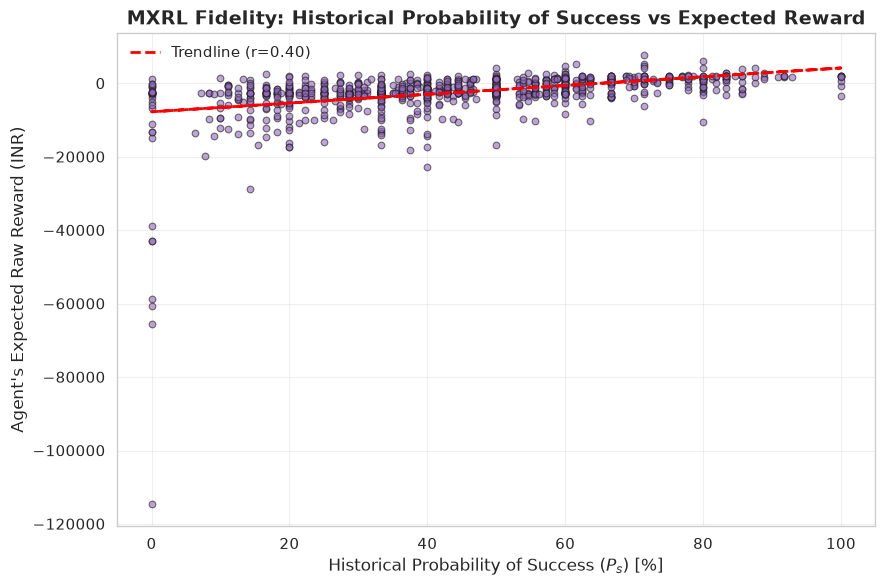

In [76]:
plt.figure(figsize=(9, 6))
plt.scatter(
    mxrl_p_s_values * 100,
    agent_expected_rewards,
    alpha=0.6,
    color="#9467bd",
    edgecolor="k",
)

# Fit a trendline
m, b = np.polyfit(mxrl_p_s_values * 100, agent_expected_rewards, 1)
plt.plot(
    mxrl_p_s_values * 100,
    m * (mxrl_p_s_values * 100) + b,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Trendline (r={correlation:.2f})",
)

plt.title(
    "MXRL Fidelity: Historical Probability of Success vs Expected Reward", fontsize=14
)
plt.xlabel("Historical Probability of Success ($P_s$) [%]", fontsize=12)
plt.ylabel("Agent's Expected Raw Reward (INR)", fontsize=12)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(
    "./plots/LMUT_MOET_Combined_Training_Losses.pdf",
    format="pdf",
    dpi=1200,
    bbox_inches="tight",
)
plt.show()